# CIFAR-10 CNN Regularization and Training Optimization

This notebook develops generalization and training performance through early stopping,
regularization, dropout, batch normalization, learning-rate control, mirrored data, and combined
architecture improvements.

## Early Stopping, Mirroring, Dropout, and Batch Normalization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from keras import callbacks
import cv2 as cv

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time

In [2]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('Final shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2073s 12us/step
Final shapes
x_train.shape = (50000, 32, 32, 3)
y_train.shape = (50000, 10)
x_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 10)


Let's see some of the images in the dataset and their mirrored versions:

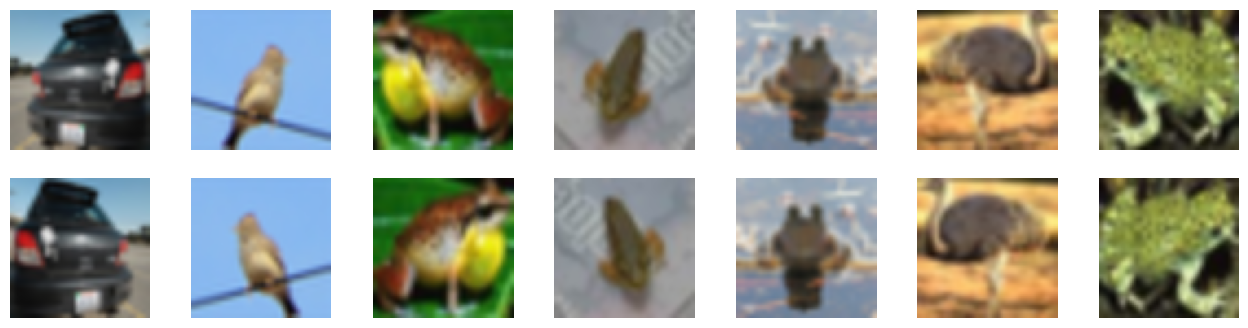

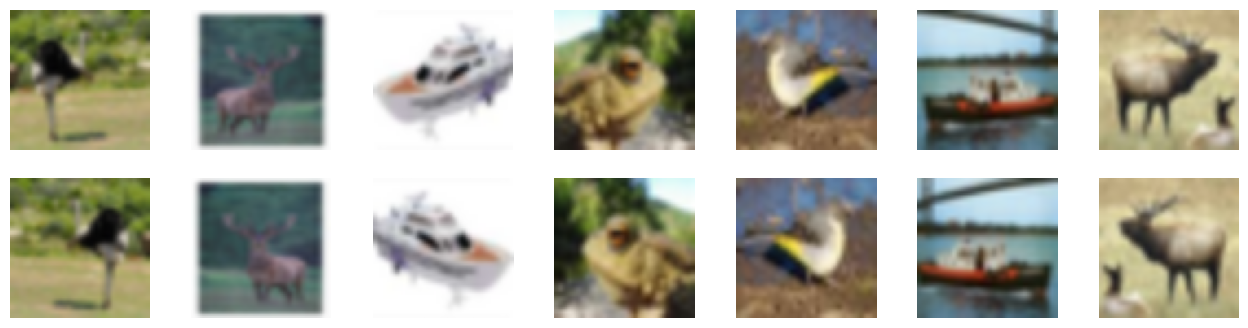

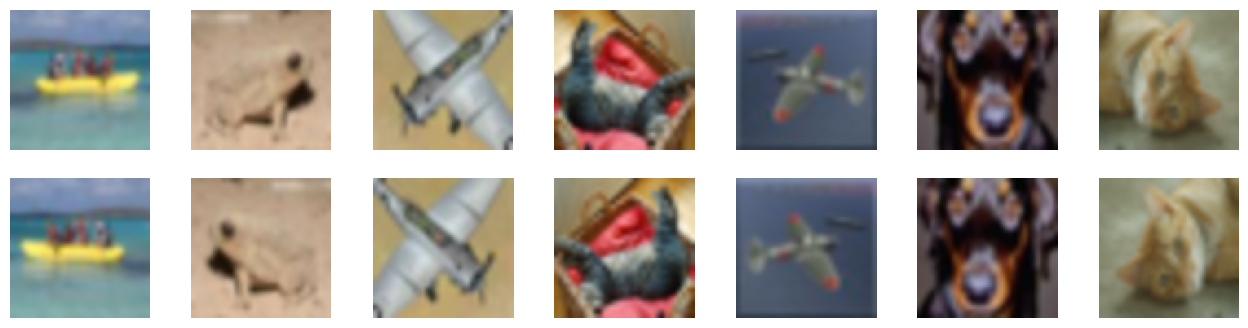

In [4]:
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 7)
  k = 2
  fig, ax = plt.subplots(nrows=2,ncols=len(sel), figsize=(16,4))
  for i,s in enumerate(sel):
    ax[0,i].imshow(cv.resize(x_train[s], (32*k, 32*k)))
    ax[1,i].imshow(cv.resize(x_train[s,:,::-1], (32*k, 32*k)))
    ax[0,i].set_axis_off()
    ax[1,i].set_axis_off()

## Baseline CNN with Early Stopping

Instead of running the fit process for a fixed number of epochs, we will add an instruction to stop if results don't improve for a predetermined number of epochs.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,730 (424.73 KB)

 Trainable params: 108,730 (424.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
500/500 - 11s - 21ms/step - accuracy: 0.4162 - loss: 1.6070 - val_accuracy: 0.5173 - val_loss: 1.3641
Epoch 2/100
500/500 - 2s - 3ms/step - accuracy: 0.5739 - loss: 1.2058 - val_accuracy: 0.6125 - val_loss: 1.1083
Epoch 3/100
500/500 - 2s - 3ms/step - accuracy: 0.6298 - loss: 1.0495 - val_accuracy: 0.6419 - val_loss: 1.0181
Epoch 4/100
500/500 - 2s - 3ms/step - accuracy: 0.6654 - loss: 0.9569 - val_accuracy: 0.6678 - val_loss: 0.9685
Epoch 5/100
500/500 - 2s - 3ms/step - accuracy: 0.6936 - loss: 0.8783 - val_accuracy: 0.6888 - val_loss: 0.9138
Epoch 6/100
500/500 - 2s - 3ms/step - accuracy: 0.7097 - loss: 0.8347 - val_accuracy: 0.6716 - val_loss: 0.9488
Epoch 7/100
500/500 - 2s - 3ms/step - accuracy: 0.7284 - loss: 0.7851 - val_accuracy: 0.7044 - val_loss: 0.8626
Epoch 8/100
500/500 - 2s - 3ms/step - accuracy: 0.7442 - loss: 0.7413 - val_accuracy: 0.7067 - val_loss: 0.8643
Epoch 9/100
500/500 - 2s - 3ms/step - accuracy: 0.7549 - loss: 0.7042 - val_accuracy: 0.7097 - val_los

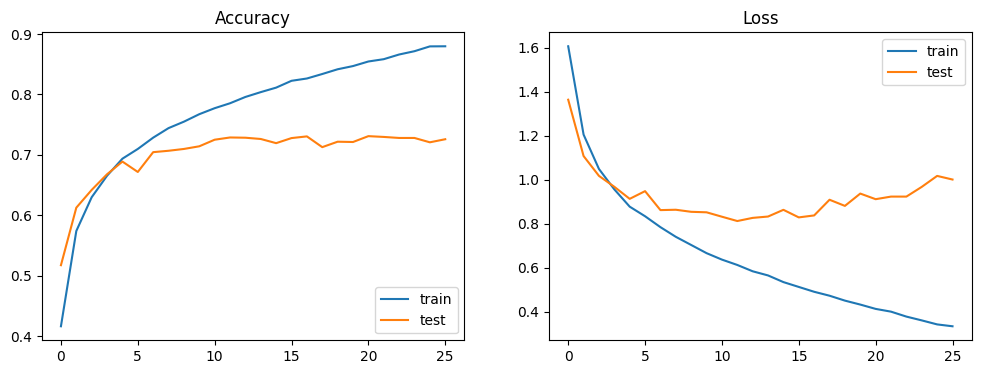

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Elapsed time training= 52.8836 secs
Accuracy = 0.7310


In [5]:
earlystopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 100,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
    callbacks = [earlystopping]
)
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print_best_metrics(history.history)
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## Back-to-Back Convolutional Layers

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
500/500 - 8s - 16ms/step - accuracy: 0.4226 - loss: 1.5720 - val_accuracy: 0.5635 - val_loss: 1.2084
Epoch 2/100
500/500 - 2s - 4ms/step - accuracy: 0.6023 - loss: 1.1140 - val_accuracy: 0.6436 - val_loss: 1.0047
Epoch 3/100
500/500 - 2s - 4ms/step - accuracy: 0.6808 - loss: 0.9080 - val_accuracy: 0.7021 - val_loss: 0.8572
Epoch 4/100
500/500 - 2s - 4ms/step - accuracy: 0.7250 - loss: 0.7875 - val_accuracy: 0.7148 - val_loss: 0.8214
Epoch 5/100
500/500 - 2s - 4ms/step - accuracy: 0.7605 - loss: 0.6862 - val_accuracy: 0.7358 - val_loss: 0.7643
Epoch 6/100
500/500 - 2s - 4ms/step - accuracy: 0.7829 - loss: 0.6172 - val_accuracy: 0.7590 - val_loss: 0.7191
Epoch 7/100
500/500 - 2s - 4ms/step - accuracy: 0.8056 - loss: 0.5546 - val_accuracy: 0.7470 - val_loss: 0.7794
Epoch 8/100
500/500 - 2s - 4ms/step - accuracy: 0.8254 - loss: 0.4968 - val_accuracy: 0.7637 - val_loss: 0.7279
Epoch 9/100
500/500 - 2s - 4ms/step - accuracy: 0.8410 - loss: 0.4530 - val_accuracy: 0.7613 - val_loss

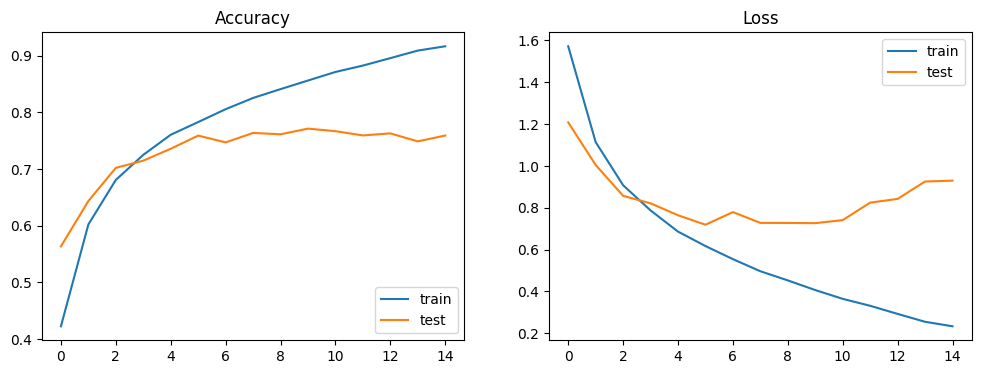

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Elapsed time training= 37.0282 secs
Accuracy = 0.7714


In [6]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 100,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
    callbacks = [earlystopping]
)
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print_best_metrics(history.history)
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## Mirrored Training Data

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5054 - loss: 1.3583 - val_accuracy: 0.6501 - val_loss: 0.9959
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6965 - loss: 0.8649 - val_accuracy: 0.7211 - val_loss: 0.7974
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7568 - loss: 0.6952 - val_accuracy: 0.7542 - val_loss: 0.6860
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7937 - loss: 0.5949 - val_accuracy: 0.7824 - val_loss: 0.6262
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8148 - loss: 0.5295 - val_accuracy: 0.7880 - val_loss: 0.6226
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8331 - loss: 0.4766 - val_accuracy: 0.7910 - val_loss: 0.6024
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8473 - loss: 0.4351 - val_accuracy: 0.7977 - val_loss: 0.5928
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8620 - loss: 

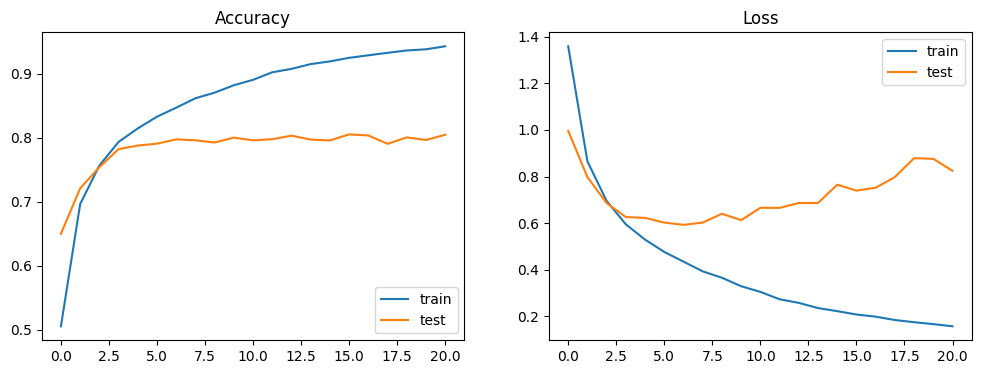

The highest training accuracy was 0.9432 obtained in epoch 21
The final training accuracy was 0.9432
The highest validation accuracy was 0.8055 obtained in epoch 16
The final validation accuracy was 0.8049
The lowest training loss was 0.1580 obtained in epoch 21
The final training loss was 0.1580
The lowest validation loss was 0.5928 obtained in epoch 7
The final validation loss was 0.8245
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Elapsed time training= 87.0536 secs
Mean squared error = 0.030
Accuracy = 0.8055


In [7]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## Mirrored Test-Time Evaluation

Since the training is identical, we don't need to retrain the model. We will use the model from the previous experiment.

In [8]:
y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))

Model accuracy on test set: 0.8055
Model accuracy on mirrored test set: 0.8042
Model accuracy on combined original and mirrored test set: 0.8345


## Dropout

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4080 - loss: 1.6073 - val_accuracy: 0.5723 - val_loss: 1.1842
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5969 - loss: 1.1348 - val_accuracy: 0.6695 - val_loss: 0.9346
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6624 - loss: 0.9651 - val_accuracy: 0.7152 - val_loss: 0.8221
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6970 - loss: 0.8713 - val_accuracy: 0.7442 - val_loss: 0.7433
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7226 - loss: 0.8061 - val_accuracy: 0.7501 - val_loss: 0.7212
Elapsed time training= 30.6877 secs


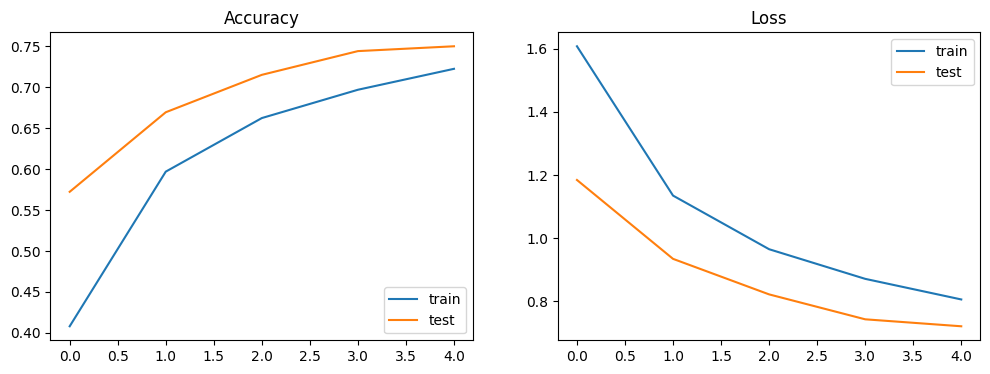

The highest training accuracy was 0.7226 obtained in epoch 5
The final training accuracy was 0.7226
The highest validation accuracy was 0.7501 obtained in epoch 5
The final validation accuracy was 0.7501
The lowest training loss was 0.8061 obtained in epoch 5
The final training loss was 0.8061
The lowest validation loss was 0.7212 obtained in epoch 5
The final validation loss was 0.7212
Model accuracy on test set: 0.5723
Model accuracy on mirrored test set: 0.5719
Model accuracy on combined original and mirrored test set: 0.5841


In [9]:
def cnn(input_shape, conv_units,dense_units,dropout_rate):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64,0.25)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)
print_best_metrics(history.history)

y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))

## Batch Normalization

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,522 (689.54 KB)

 Trainable params: 176,106 (687.91 KB)

 Non-trainable params: 416 (1.62 KB)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.5022 - loss: 1.3942 - val_accuracy: 0.5969 - val_loss: 1.1100
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6766 - loss: 0.9213 - val_accuracy: 0.6659 - val_loss: 0.9474
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7277 - loss: 0.7761 - val_accuracy: 0.7464 - val_loss: 0.7534
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7571 - loss: 0.6974 - val_accuracy: 0.7503 - val_loss: 0.7336
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7760 - loss: 0.6462 - val_accuracy: 0.7828 - val_loss: 0.6295
Elapsed time training= 33.3440 secs


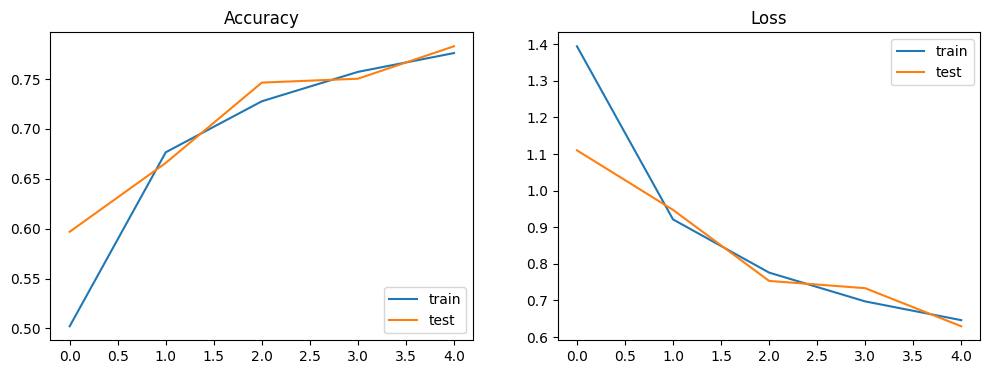

The highest training accuracy was 0.7760 obtained in epoch 5
The final training accuracy was 0.7760
The highest validation accuracy was 0.7828 obtained in epoch 5
The final validation accuracy was 0.7828
The lowest training loss was 0.6462 obtained in epoch 5
The final training loss was 0.6462
The lowest validation loss was 0.6295 obtained in epoch 5
The final validation loss was 0.6295
Model accuracy on test set: 0.5969
Model accuracy on mirrored test set: 0.6006
Model accuracy on combined original and mirrored test set: 0.6092


In [10]:
def cnn(input_shape, conv_units,dense_units,dropout_rate):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64,0.25)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)
print_best_metrics(history.history)

y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))

## Sparse-Label CNN Improvements and Regularization

## CIFAR-10 Convolutional Classification

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from keras import callbacks, regularizers
import time
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

In [21]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)

In [22]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
X_train = np.float32(X_train/255.0)
X_test = np.float32(X_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [23]:
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(50000, 32, 32, 3)
X_test.shape=(10000, 32, 32, 3)
y_train.shape=(50000, 1)
y_test.shape=(10000, 1)


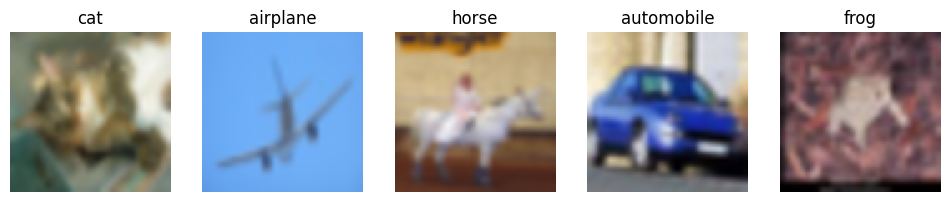

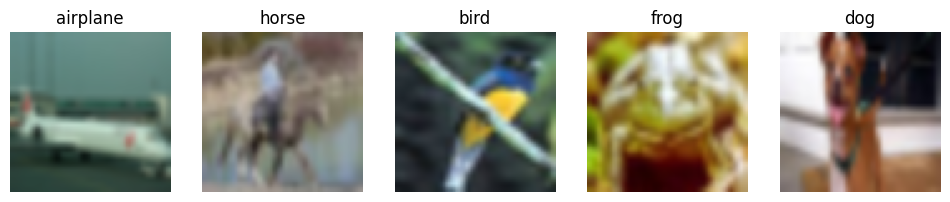

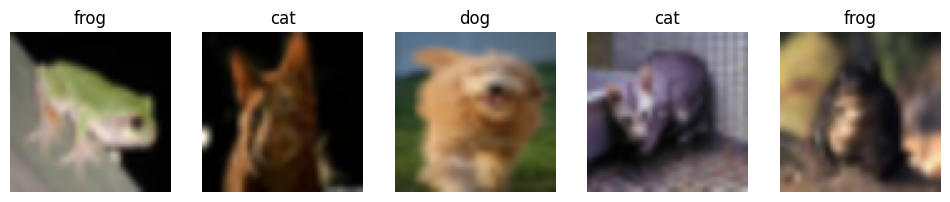

In [24]:
for k in range(3):
  sel = np.random.randint(0,X_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(X_train[s].reshape(32,32,3), (32*k, 32*k)))
    ax[i].set_title(label[y_train[s,0]])
    ax[i].set_axis_off()

### Baseline Sparse-Label Model

We will change the loss function to "sparse_categorical_crossentropy". It is equivalent to "categorical_crossentropy", but it expects a 1D array as output and perform the conversion to one-hot representation internally.

Input shape: (32, 32, 3)
Number of classes: 10
Type of num_classes: <class 'int'>


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547,810 (2.09 MB)

 Trainable params: 547,810 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
100/100 - 9s - 91ms/step - accuracy: 0.3685 - loss: 1.7386 - val_accuracy: 0.4946 - val_loss: 1.4169
Epoch 2/20
100/100 - 1s - 9ms/step - accuracy: 0.5353 - loss: 1.3037 - val_accuracy: 0.5768 - val_loss: 1.1873
Epoch 3/20
100/100 - 1s - 9ms/step - accuracy: 0.6059 - loss: 1.1214 - val_accuracy: 0.6212 - val_loss: 1.0809
Epoch 4/20
100/100 - 1s - 9ms/step - accuracy: 0.6492 - loss: 1.0040 - val_accuracy: 0.6508 - val_loss: 1.0014
Epoch 5/20
100/100 - 1s - 9ms/step - accuracy: 0.6817 - loss: 0.9166 - val_accuracy: 0.6740 - val_loss: 0.9306
Epoch 6/20
100/100 - 1s - 9ms/step - accuracy: 0.7019 - loss: 0.8616 - val_accuracy: 0.6973 - val_loss: 0.8844
Epoch 7/20
100/100 - 1s - 9ms/step - accuracy: 0.7286 - loss: 0.7890 - val_accuracy: 0.7034 - val_loss: 0.8588
Epoch 8/20
100/100 - 1s - 9ms/step - accuracy: 0.7434 - loss: 0.7469 - val_accuracy: 0.6978 - val_loss: 0.8831
Epoch 9/20
100/100 - 1s - 9ms/step - accuracy: 0.7578 - loss: 0.7062 - val_accuracy: 0.7209 - val_loss: 0.8161


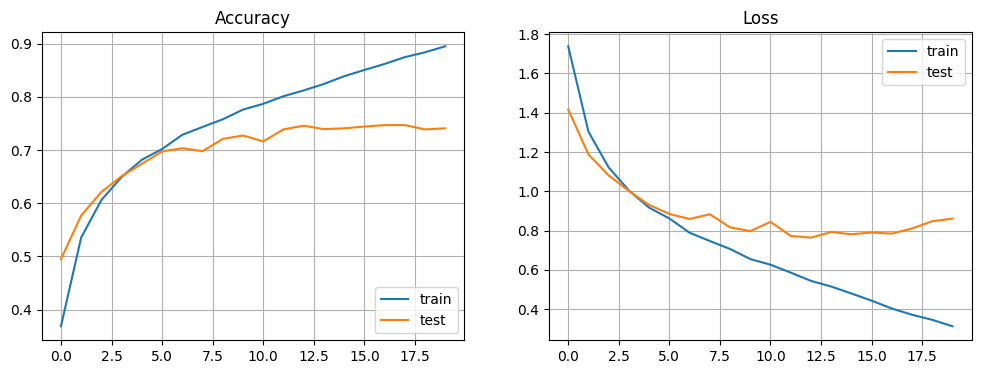

In [26]:
def cnn(input_shape, conv_units, dense_units, out_units):

    model = tf.keras.Sequential()
    model.add(Input(shape=input_shape))

    for c in conv_units:
        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation="relu",
                padding="same"
            )
        )
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dense(out_units, activation="softmax"))

    return model


# CIFAR-10 has 10 classes
num_classes = int(np.max(y_train) + 1)

print("Input shape:", X_train.shape[1:])
print("Number of classes:", num_classes)
print("Type of num_classes:", type(num_classes))

model = cnn(
    X_train.shape[1:],
    [50, 100, 200],
    100,
    num_classes
)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test),
)

end_train = time.time()

plot_results(history)

pred = model.predict(X_test)

print(
    "Elapsed time training = {:.4f} secs".format(
        end_train - start_train
    )
)

pred_int = np.argmax(pred, axis=1)

print(
    "Accuracy = {:.4f}".format(
        accuracy_score(y_test.ravel(), pred_int)
    )
)

## CNN Improvement Experiments

## Early Stopping and Best-Weight Restoration

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547,810 (2.09 MB)

 Trainable params: 547,810 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
100/100 - 5s - 53ms/step - accuracy: 0.3670 - loss: 1.7495 - val_accuracy: 0.4927 - val_loss: 1.4326
Epoch 2/200
100/100 - 1s - 10ms/step - accuracy: 0.5260 - loss: 1.3286 - val_accuracy: 0.5569 - val_loss: 1.2208
Epoch 3/200
100/100 - 1s - 9ms/step - accuracy: 0.5975 - loss: 1.1491 - val_accuracy: 0.6034 - val_loss: 1.1146
Epoch 4/200
100/100 - 1s - 9ms/step - accuracy: 0.6381 - loss: 1.0328 - val_accuracy: 0.6535 - val_loss: 1.0009
Epoch 5/200
100/100 - 1s - 9ms/step - accuracy: 0.6740 - loss: 0.9456 - val_accuracy: 0.6739 - val_loss: 0.9329
Epoch 6/200
100/100 - 1s - 9ms/step - accuracy: 0.6957 - loss: 0.8766 - val_accuracy: 0.6862 - val_loss: 0.8964
Epoch 7/200
100/100 - 1s - 9ms/step - accuracy: 0.7218 - loss: 0.8060 - val_accuracy: 0.6965 - val_loss: 0.8807
Epoch 8/200
100/100 - 1s - 9ms/step - accuracy: 0.7361 - loss: 0.7636 - val_accuracy: 0.7176 - val_loss: 0.8269
Epoch 9/200
100/100 - 1s - 9ms/step - accuracy: 0.7496 - loss: 0.7256 - val_accuracy: 0.7303 - val_los

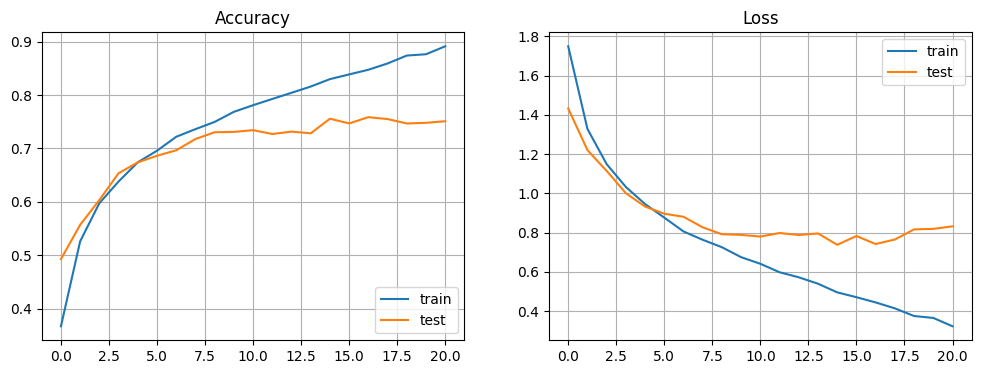

In [28]:
earlystopping = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)


def cnn(input_shape, conv_units, dense_units, out_units):

    model = tf.keras.Sequential()
    model.add(Input(shape=input_shape))

    for c in conv_units:
        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation="relu",
                padding="same"
            )
        )
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dense(out_units, activation="softmax"))

    return model


# CIFAR-10 contains 10 classes
num_classes = 10

model = cnn(
    X_train.shape[1:],
    [50, 100, 200],
    100,
    num_classes
)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test),
    callbacks=[earlystopping]
)

end_train = time.time()

plot_results(history)

pred = model.predict(X_test)

print(
    "Elapsed time training = {:.4f} secs".format(
        end_train - start_train
    )
)

pred_int = np.argmax(pred, axis=1)

print(
    "Accuracy = {:.4f}".format(
        accuracy_score(y_test.ravel(), pred_int)
    )
)

## Back-to-Back Convolutions

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,020,660 (3.89 MB)

 Trainable params: 1,020,660 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
100/100 - 10s - 96ms/step - accuracy: 0.3375 - loss: 1.7952 - val_accuracy: 0.4504 - val_loss: 1.4803
Epoch 2/200
100/100 - 2s - 16ms/step - accuracy: 0.5155 - loss: 1.3397 - val_accuracy: 0.5694 - val_loss: 1.1880
Epoch 3/200
100/100 - 2s - 16ms/step - accuracy: 0.6150 - loss: 1.0863 - val_accuracy: 0.6527 - val_loss: 0.9942
Epoch 4/200
100/100 - 2s - 16ms/step - accuracy: 0.6805 - loss: 0.9167 - val_accuracy: 0.6855 - val_loss: 0.8970
Epoch 5/200
100/100 - 2s - 16ms/step - accuracy: 0.7193 - loss: 0.8066 - val_accuracy: 0.7095 - val_loss: 0.8399
Epoch 6/200
100/100 - 2s - 16ms/step - accuracy: 0.7515 - loss: 0.7091 - val_accuracy: 0.7200 - val_loss: 0.8149
Epoch 7/200
100/100 - 2s - 16ms/step - accuracy: 0.7838 - loss: 0.6224 - val_accuracy: 0.7546 - val_loss: 0.7272
Epoch 8/200
100/100 - 2s - 16ms/step - accuracy: 0.8101 - loss: 0.5485 - val_accuracy: 0.7526 - val_loss: 0.7215
Epoch 9/200
100/100 - 2s - 16ms/step - accuracy: 0.8328 - loss: 0.4793 - val_accuracy: 0.7635 -

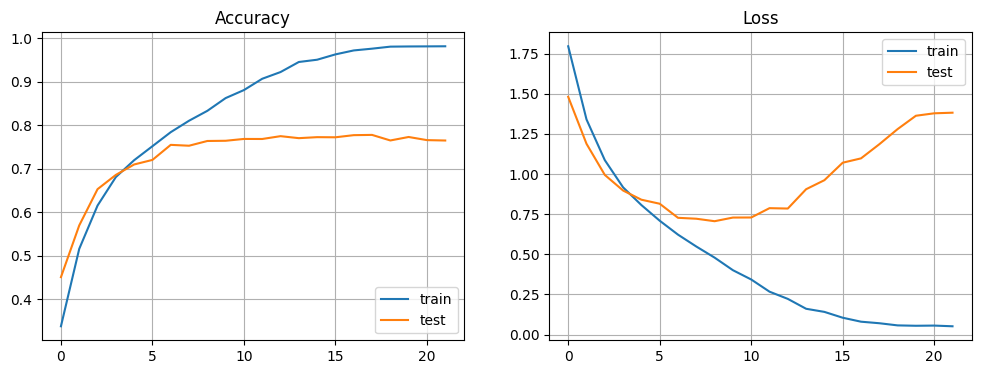

In [30]:
earlystopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

def cnn(input_shape, conv_units, dense_units, out_units):

    model = tf.keras.Sequential()
    model.add(Input(shape=input_shape))

    for c in conv_units:
        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation="relu",
                padding='same'
            )
        )

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation="relu",
                padding='same'
            )
        )

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(out_units, activation='softmax'))

    return model


num_classes = 10

model = cnn(
    X_train.shape[1:],
    [50, 100, 200],
    100,
    num_classes
)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test),
    callbacks=[earlystopping]
)

end_train = time.time()

plot_results(history)

pred = model.predict(X_test)

print(
    'Elapsed time training= {:.4f} secs'.format(
        end_train - start_train
    )
)

pred_int = np.argmax(pred, axis=1)

print(
    'Accuracy = {:.4f}'.format(
        accuracy_score(y_test.ravel(), pred_int)
    )
)

## Mirrored Training Data

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_69 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,020,660 (3.89 MB)

 Trainable params: 1,020,660 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

Original training shape: (50000, 32, 32, 3)
Augmented training shape: (100000, 32, 32, 3)
Epoch 1/200
200/200 - 9s - 43ms/step - accuracy: 0.4147 - loss: 1.6037 - val_accuracy: 0.5594 - val_loss: 1.2278
Epoch 2/200
200/200 - 3s - 15ms/step - accuracy: 0.6397 - loss: 1.0201 - val_accuracy: 0.6989 - val_loss: 0.8605
Epoch 3/200
200/200 - 3s - 15ms/step - accuracy: 0.7289 - loss: 0.7728 - val_accuracy: 0.7433 - val_loss: 0.7344
Epoch 4/200
200/200 - 3s - 15ms/step - accuracy: 0.7803 - loss: 0.6348 - val_accuracy: 0.7736 - val_loss: 0.6430
Epoch 5/200
200/200 - 3s - 15ms/step - accuracy: 0.8167 - loss: 0.5289 - val_accuracy: 0.7928 - val_loss: 0.6074
Epoch 6/200
200/200 - 3s - 15ms/step - accuracy: 0.8427 - loss: 0.4527 - val_accuracy: 0.8062 - val_loss: 0.5796
Epoch 7/200
200/200 - 3s - 15ms/step - accuracy: 0.8673 - loss: 0.3830 - val_accuracy: 0.8158 - val_loss: 0.5626
Epoch 8/200
200/200 - 3s - 15ms/step - accuracy: 0.8890 - loss: 0.3192 - val_accuracy: 0.8166 - val_loss: 0.5794
Epoch 

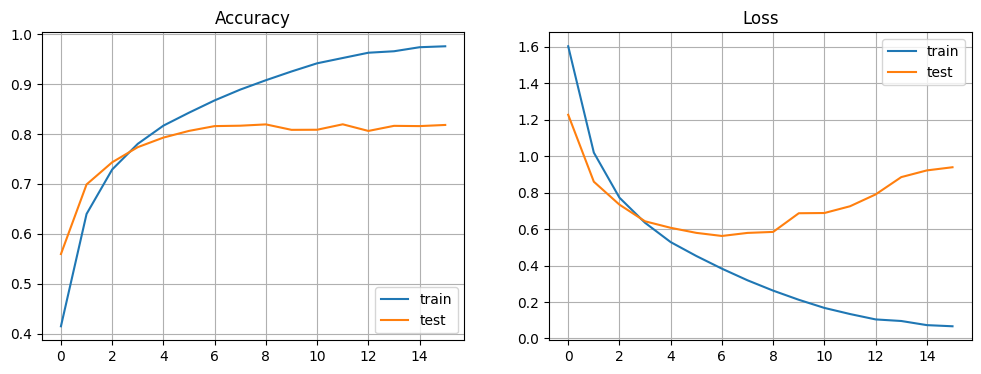

In [33]:
earlystopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

def cnn(input_shape, conv_units, dense_units, out_units):

    model = tf.keras.Sequential()
    model.add(Input(shape=input_shape))

    for c in conv_units:
        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same'
            )
        )

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same'
            )
        )

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(out_units, activation='softmax'))

    return model


num_classes = int(np.max(y_train) + 1)

model = cnn(
    X_train.shape[1:],
    [50, 100, 200],
    100,
    num_classes
)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Add horizontally mirrored images to the training set
X_train_aug = np.append(
    X_train,
    X_train[:, :, ::-1],
    axis=0
)

y_train_aug = np.append(
    y_train,
    y_train,
    axis=0
)

print("Original training shape:", X_train.shape)
print("Augmented training shape:", X_train_aug.shape)

start_train = time.time()

history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=200,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test),
    callbacks=[earlystopping]
)

end_train = time.time()

plot_results(history)

pred = model.predict(X_test)

print(
    'Elapsed time training = {:.4f} secs'.format(
        end_train - start_train
    )
)

pred_int = np.argmax(pred, axis=1)

print(
    'Accuracy = {:.4f}'.format(
        accuracy_score(y_test.ravel(), pred_int)
    )
)

## Mirrored Test-Time Prediction

In [34]:
pred1 = model.predict(X_test,verbose=0) # Prediction
pred2 = model.predict(X_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test)))

Model accuracy on test set: 0.8194
Model accuracy on mirrored test set: 0.8189
Model accuracy on combined original and mirrored test set: 0.8379


## L1/L2 Regularization

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_81 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,020,660 (3.89 MB)

 Trainable params: 1,020,660 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
200/200 - 11s - 53ms/step - accuracy: 0.4033 - loss: 1.7737 - val_accuracy: 0.5323 - val_loss: 1.4114
Epoch 2/200
200/200 - 3s - 15ms/step - accuracy: 0.6041 - loss: 1.2529 - val_accuracy: 0.6614 - val_loss: 1.1019
Epoch 3/200
200/200 - 3s - 15ms/step - accuracy: 0.6907 - loss: 1.0253 - val_accuracy: 0.6983 - val_loss: 1.0016
Epoch 4/200
200/200 - 3s - 15ms/step - accuracy: 0.7406 - loss: 0.8962 - val_accuracy: 0.7446 - val_loss: 0.8871
Epoch 5/200
200/200 - 3s - 15ms/step - accuracy: 0.7797 - loss: 0.7935 - val_accuracy: 0.7721 - val_loss: 0.8349
Epoch 6/200
200/200 - 3s - 15ms/step - accuracy: 0.8060 - loss: 0.7294 - val_accuracy: 0.7870 - val_loss: 0.7992
Epoch 7/200
200/200 - 3s - 15ms/step - accuracy: 0.8285 - loss: 0.6694 - val_accuracy: 0.7953 - val_loss: 0.7833
Epoch 8/200
200/200 - 3s - 15ms/step - accuracy: 0.8450 - loss: 0.6295 - val_accuracy: 0.8011 - val_loss: 0.7744
Epoch 9/200
200/200 - 3s - 15ms/step - accuracy: 0.8626 - loss: 0.5868 - val_accuracy: 0.8097 -

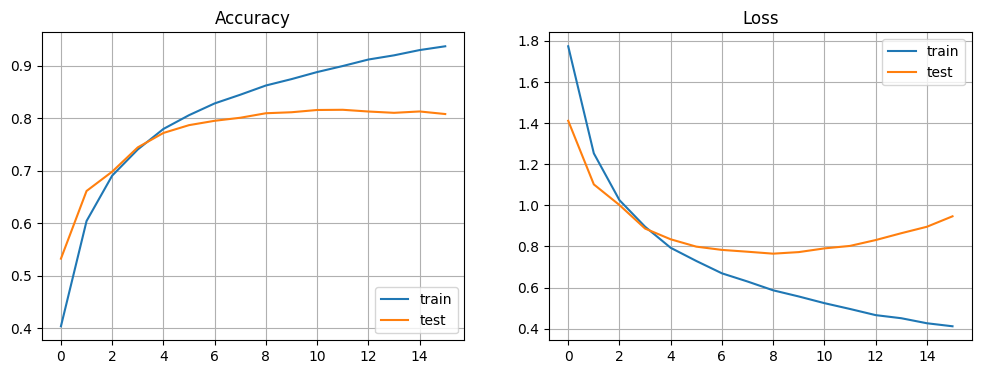

In [36]:
earlystopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

def cnn(input_shape, conv_units, dense_units, out_units):

    model = tf.keras.Sequential()
    model.add(Input(shape=input_shape))

    for c in conv_units:

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation="relu",
                padding='same',
                kernel_regularizer=regularizers.L1L2(
                    l1=1e-5,
                    l2=1e-4
                )
            )
        )

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation="relu",
                padding='same',
                kernel_regularizer=regularizers.L1L2(
                    l1=1e-5,
                    l2=1e-4
                )
            )
        )

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(
        Dense(
            dense_units,
            activation='relu',
            kernel_regularizer=regularizers.L1L2(
                l1=1e-5,
                l2=1e-4
            )
        )
    )

    model.add(Dense(out_units, activation='softmax'))

    return model


num_classes = int(np.max(y_train) + 1)

model = cnn(
    X_train.shape[1:],
    [50, 100, 200],
    100,
    num_classes
)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Add horizontally mirrored images to the training data
X_train_aug = np.append(
    X_train,
    X_train[:, :, ::-1],
    axis=0
)

y_train_aug = np.append(
    y_train,
    y_train,
    axis=0
)

start_train = time.time()

history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=200,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test),
    callbacks=[earlystopping]
)

end_train = time.time()

plot_results(history)

pred = model.predict(X_test, verbose=0)

pred_int = np.argmax(pred, axis=1)

print(
    'Elapsed time training = {:.4f} secs'.format(
        end_train - start_train
    )
)

print(
    'Accuracy = {:.4f}'.format(
        accuracy_score(y_test.ravel(), pred_int)
    )
)

## Dropout

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_93 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,020,660 (3.89 MB)

 Trainable params: 1,020,660 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
100/100 - 12s - 122ms/step - accuracy: 0.2330 - loss: 2.2290 - val_accuracy: 0.3932 - val_loss: 1.7974
Epoch 2/200
100/100 - 2s - 17ms/step - accuracy: 0.3951 - loss: 1.7405 - val_accuracy: 0.4705 - val_loss: 1.5520
Epoch 3/200
100/100 - 2s - 16ms/step - accuracy: 0.4751 - loss: 1.5323 - val_accuracy: 0.5299 - val_loss: 1.3869
Epoch 4/200
100/100 - 2s - 16ms/step - accuracy: 0.5354 - loss: 1.3844 - val_accuracy: 0.5964 - val_loss: 1.2411
Epoch 5/200
100/100 - 2s - 16ms/step - accuracy: 0.5870 - loss: 1.2631 - val_accuracy: 0.6085 - val_loss: 1.2028
Epoch 6/200
100/100 - 2s - 16ms/step - accuracy: 0.6133 - loss: 1.1940 - val_accuracy: 0.6590 - val_loss: 1.0789
Epoch 7/200
100/100 - 2s - 16ms/step - accuracy: 0.6385 - loss: 1.1303 - val_accuracy: 0.6729 - val_loss: 1.0425
Epoch 8/200
100/100 - 2s - 16ms/step - accuracy: 0.6629 - loss: 1.0712 - val_accuracy: 0.6935 - val_loss: 0.9835
Epoch 9/200
100/100 - 2s - 16ms/step - accuracy: 0.6754 - loss: 1.0440 - val_accuracy: 0.7000 

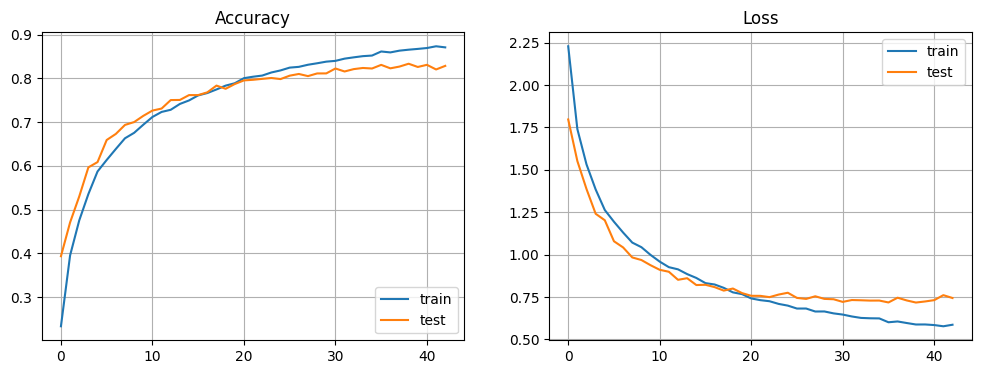

In [38]:
earlystopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)


def cnn(input_shape, conv_units, dense_units, out_units, dropout_rate=0.25):

    model = tf.keras.Sequential()
    model.add(Input(shape=input_shape))

    for c in conv_units:

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same',
                kernel_regularizer=regularizers.L1L2(
                    l1=1e-5,
                    l2=1e-4
                )
            )
        )

        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same',
                kernel_regularizer=regularizers.L1L2(
                    l1=1e-5,
                    l2=1e-4
                )
            )
        )

        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(dropout_rate))

    model.add(Flatten())

    model.add(
        Dense(
            dense_units,
            activation='relu',
            kernel_regularizer=regularizers.L1L2(
                l1=1e-5,
                l2=1e-4
            )
        )
    )

    model.add(Dropout(dropout_rate))

    model.add(
        Dense(
            out_units,
            activation='softmax'
        )
    )

    return model


# Number of CIFAR-10 classes
num_classes = int(np.max(y_train) + 1)

model = cnn(
    X_train.shape[1:],
    [50, 100, 200],
    100,
    num_classes
)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test),
    callbacks=[earlystopping]
)

end_train = time.time()

plot_results(history)

# Prediction on original test images
pred1 = model.predict(X_test, verbose=0)

pred_int = np.argmax(pred1, axis=1)

print(
    'Elapsed time training = {:.4f} secs'.format(
        end_train - start_train
    )
)

print(
    'Accuracy = {:.4f}'.format(
        accuracy_score(
            y_test.ravel(),
            pred_int
        )
    )
)


# Prediction on horizontally mirrored test images
pred2 = model.predict(
    X_test[:, :, ::-1],
    verbose=0
)

print(
    'Model accuracy on test set: {:.4f}'.format(
        accuracy_score(
            y_test.ravel(),
            np.argmax(pred1, axis=1)
        )
    )
)

print(
    'Model accuracy on mirrored test set: {:.4f}'.format(
        accuracy_score(
            y_test.ravel(),
            np.argmax(pred2, axis=1)
        )
    )
)


# Combine predictions from original and mirrored images
avg_pred = (pred1 + pred2) / 2

print(
    'Model accuracy on combined original and mirrored test set: {:.4f}'.format(
        accuracy_score(
            y_test.ravel(),
            np.argmax(avg_pred, axis=1)
        )
    )
)

## Batch Normalization

X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000, 1)
y_test shape: (10000, 1)
y_train_oh shape: (50000, 10)
y_test_oh shape: (10000, 10)
Number of classes: 10


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_99 (Conv2D)              │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 100)      │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 200)      │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,460 (3.90 MB)

 Trainable params: 1,021,560 (3.90 MB)

 Non-trainable params: 900 (3.52 KB)


Original training data:
X_train: (50000, 32, 32, 3)
y_train_oh: (50000, 10)

Augmented training data:
X_train_aug: (100000, 32, 32, 3)
y_train_aug: (100000, 10)
Epoch 1/100
1000/1000 - 18s - 18ms/step - accuracy: 0.5896 - loss: 1.1687 - val_accuracy: 0.6735 - val_loss: 0.9587
Epoch 2/100
1000/1000 - 5s - 5ms/step - accuracy: 0.7533 - loss: 0.7048 - val_accuracy: 0.7638 - val_loss: 0.6823
Epoch 3/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8006 - loss: 0.5771 - val_accuracy: 0.8065 - val_loss: 0.5592
Epoch 4/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8271 - loss: 0.5000 - val_accuracy: 0.8264 - val_loss: 0.5123
Epoch 5/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8486 - loss: 0.4407 - val_accuracy: 0.8406 - val_loss: 0.4765
Epoch 6/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8643 - loss: 0.3913 - val_accuracy: 0.8109 - val_loss: 0.5716
Epoch 7/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8758 - loss: 0.3567 - val_accuracy: 0.8541 - val_loss: 0.4405
Epoch 8/100
1000/1000 - 5s - 5ms/step 

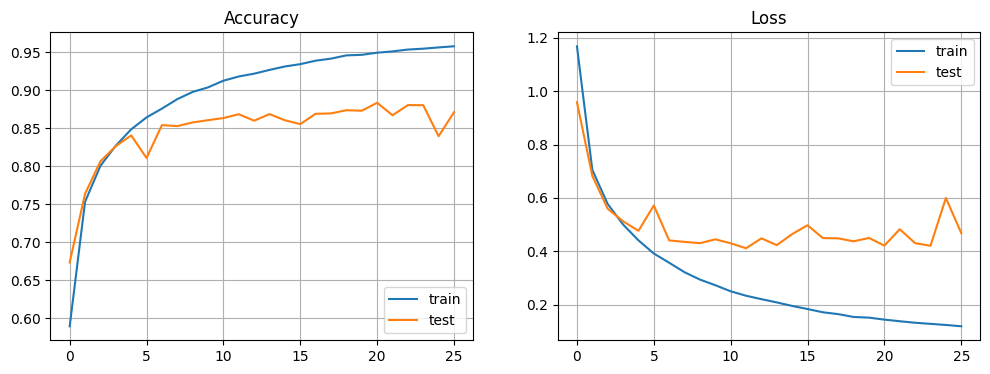

In [42]:
# Early stopping
earlystopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)


# One-hot encode the CIFAR-10 labels
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("y_train_oh shape:", y_train_oh.shape)
print("y_test_oh shape:", y_test_oh.shape)


# CNN model
def cnn(input_shape, conv_units, dense_units, out_units, dropout_rate):

    model = tf.keras.Sequential()

    model.add(Input(shape=input_shape))

    for c in conv_units:

        # First convolution
        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same'
            )
        )

        # Second convolution
        model.add(
            Conv2D(
                c,
                kernel_size=(3, 3),
                activation='relu',
                padding='same'
            )
        )

        # Downsampling
        model.add(
            MaxPooling2D(
                pool_size=(2, 2)
            )
        )

        # Normalize activations
        model.add(
            BatchNormalization()
        )

        # Reduce overfitting
        model.add(
            Dropout(dropout_rate)
        )

    # Convert convolutional feature maps to a vector
    model.add(
        Flatten()
    )

    # Dense hidden layer
    model.add(
        Dense(
            dense_units,
            activation='relu'
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        Dropout(dropout_rate)
    )

    # Output layer
    model.add(
        Dense(
            out_units,
            activation='softmax'
        )
    )

    return model


# Number of CIFAR-10 classes
num_classes = int(y_train_oh.shape[1])

print("Number of classes:", num_classes)


# Build the CNN
model = cnn(
    input_shape=X_train.shape[1:],
    conv_units=[50, 100, 200],
    dense_units=100,
    out_units=num_classes,
    dropout_rate=0.25
)


# Display model architecture
model.summary()


# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# --------------------------------------------------
# Data Augmentation: Horizontally Mirrored Images
# --------------------------------------------------

X_train_aug = np.append(
    X_train,
    X_train[:, :, ::-1],
    axis=0
)

y_train_aug = np.append(
    y_train_oh,
    y_train_oh,
    axis=0
)


print("\nOriginal training data:")
print("X_train:", X_train.shape)
print("y_train_oh:", y_train_oh.shape)

print("\nAugmented training data:")
print("X_train_aug:", X_train_aug.shape)
print("y_train_aug:", y_train_aug.shape)


# --------------------------------------------------
# Train the CNN
# --------------------------------------------------

start_train = time.time()

history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=100,
    batch_size=100,
    verbose=2,
    validation_data=(X_test, y_test_oh),
    callbacks=[earlystopping]
)

end_train = time.time()


# Plot training results
plot_results(history)


print(
    'Elapsed time training = {:.4f} secs'.format(
        end_train - start_train
    )
)


# --------------------------------------------------
# Prediction on Original Test Images
# --------------------------------------------------

pred1 = model.predict(
    X_test,
    verbose=0
)

pred1_class = np.argmax(
    pred1,
    axis=1
)

test_accuracy = accuracy_score(
    y_test.ravel(),
    pred1_class
)

print(
    'Model accuracy on original test set: {:.4f}'.format(
        test_accuracy
    )
)


# --------------------------------------------------
# Prediction on Mirrored Test Images
# --------------------------------------------------

X_test_mirrored = X_test[:, :, ::-1]

pred2 = model.predict(
    X_test_mirrored,
    verbose=0
)

pred2_class = np.argmax(
    pred2,
    axis=1
)

mirrored_accuracy = accuracy_score(
    y_test.ravel(),
    pred2_class
)

print(
    'Model accuracy on mirrored test set: {:.4f}'.format(
        mirrored_accuracy
    )
)


# --------------------------------------------------
# Combined Original + Mirrored Prediction
# --------------------------------------------------

avg_pred = (
    pred1 + pred2
) / 2

combined_class = np.argmax(
    avg_pred,
    axis=1
)

combined_accuracy = accuracy_score(
    y_test.ravel(),
    combined_class
)

print(
    'Model accuracy on combined original and mirrored test set: {:.4f}'.format(
        combined_accuracy
    )
)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_105 (Conv2D)             │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 32, 32, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 16, 16, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 100)      │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 8, 8, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 200)      │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,460 (3.90 MB)

 Trainable params: 1,021,560 (3.90 MB)

 Non-trainable params: 900 (3.52 KB)

Epoch 1/100
1000/1000 - 16s - 16ms/step - accuracy: 0.5828 - loss: 1.1888 - val_accuracy: 0.7083 - val_loss: 0.8293
Epoch 2/100
1000/1000 - 5s - 5ms/step - accuracy: 0.7479 - loss: 0.7218 - val_accuracy: 0.7091 - val_loss: 0.8771
Epoch 3/100
1000/1000 - 5s - 5ms/step - accuracy: 0.7958 - loss: 0.5908 - val_accuracy: 0.7960 - val_loss: 0.6003
Epoch 4/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8243 - loss: 0.5073 - val_accuracy: 0.7954 - val_loss: 0.5960
Epoch 5/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8454 - loss: 0.4468 - val_accuracy: 0.8001 - val_loss: 0.5750
Epoch 6/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8620 - loss: 0.3993 - val_accuracy: 0.8248 - val_loss: 0.5199
Epoch 7/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8717 - loss: 0.3648 - val_accuracy: 0.8332 - val_loss: 0.4959
Epoch 8/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8847 - loss: 0.3300 - val_accuracy: 0.7918 - val_loss: 0.6934
Epoch 9/100
1000/1000 - 5s - 5ms/step - accuracy: 0.8951 - loss: 0.3011 - val_accuracy

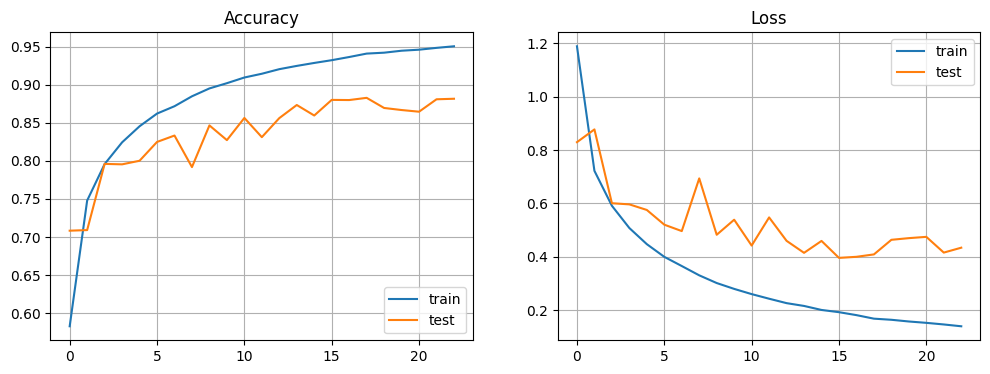

In [43]:
earlystopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

def cnn(input_shape, conv_units,dense_units,out_units,dropout_rate):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  activation="relu", padding ='same'))
    model.add(Conv2D(c, kernel_size=(3, 3),  activation="relu", padding ='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  model.add(Dense(out_units, activation='softmax'))
  return model

model = cnn(X_train.shape[1:],[50,100,200],100,y_train_oh.shape[1], 0.25)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Nadam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    np.append(X_train,X_train[:,:,::-1],axis=0), np.append(y_train_oh,y_train_oh,axis=0),
    epochs = 100,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
    callbacks = [earlystopping]
)
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))

plot_results(history)


pred1 = model.predict(X_test,verbose=0) # Prediction
pred2 = model.predict(X_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test)))

### Categorical-Crossentropy Early-Stopping Variant

This retained configuration uses one-hot labels with categorical cross-entropy and patience 5.

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_111 (Conv2D)             │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 16, 16, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ (None, 16, 16, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 8, 8, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 8, 8, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 4, 4, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547,810 (2.09 MB)

 Trainable params: 547,810 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
500/500 - 7s - 14ms/step - accuracy: 0.4564 - loss: 1.5072 - val_accuracy: 0.5795 - val_loss: 1.1731
Epoch 2/100
500/500 - 2s - 4ms/step - accuracy: 0.6301 - loss: 1.0549 - val_accuracy: 0.6728 - val_loss: 0.9216
Epoch 3/100
500/500 - 2s - 4ms/step - accuracy: 0.6932 - loss: 0.8789 - val_accuracy: 0.6832 - val_loss: 0.9143
Epoch 4/100
500/500 - 2s - 4ms/step - accuracy: 0.7402 - loss: 0.7559 - val_accuracy: 0.7219 - val_loss: 0.8184
Epoch 5/100
500/500 - 2s - 4ms/step - accuracy: 0.7691 - loss: 0.6650 - val_accuracy: 0.7444 - val_loss: 0.7391
Epoch 6/100
500/500 - 2s - 4ms/step - accuracy: 0.7965 - loss: 0.5851 - val_accuracy: 0.7454 - val_loss: 0.7473
Epoch 7/100
500/500 - 2s - 4ms/step - accuracy: 0.8251 - loss: 0.5058 - val_accuracy: 0.7511 - val_loss: 0.7547
Epoch 8/100
500/500 - 2s - 4ms/step - accuracy: 0.8448 - loss: 0.4444 - val_accuracy: 0.7408 - val_loss: 0.7856
Epoch 9/100
500/500 - 2s - 4ms/step - accuracy: 0.8660 - loss: 0.3859 - val_accuracy: 0.7508 - val_loss

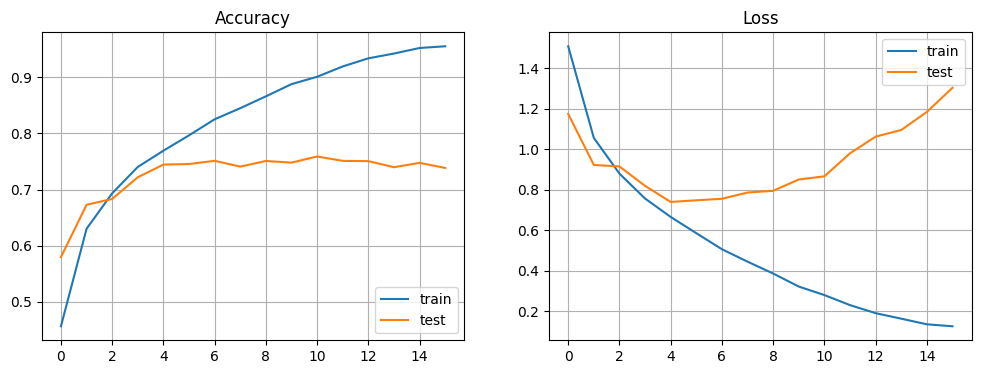

In [44]:
earlystopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

def cnn(input_shape, conv_units,dense_units,out_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  activation="relu", padding ='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(out_units, activation='softmax'))
  return model

model = cnn(X_train.shape[1:],[50,100,200],100,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 100,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
    callbacks = [earlystopping]
)
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))

plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

## L2, Batch Normalization, Dropout, Learning Rate, and Combined Improvements

In [45]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.regularizers import *
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model

from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time

In [46]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)

## L2 Regularization

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_114 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

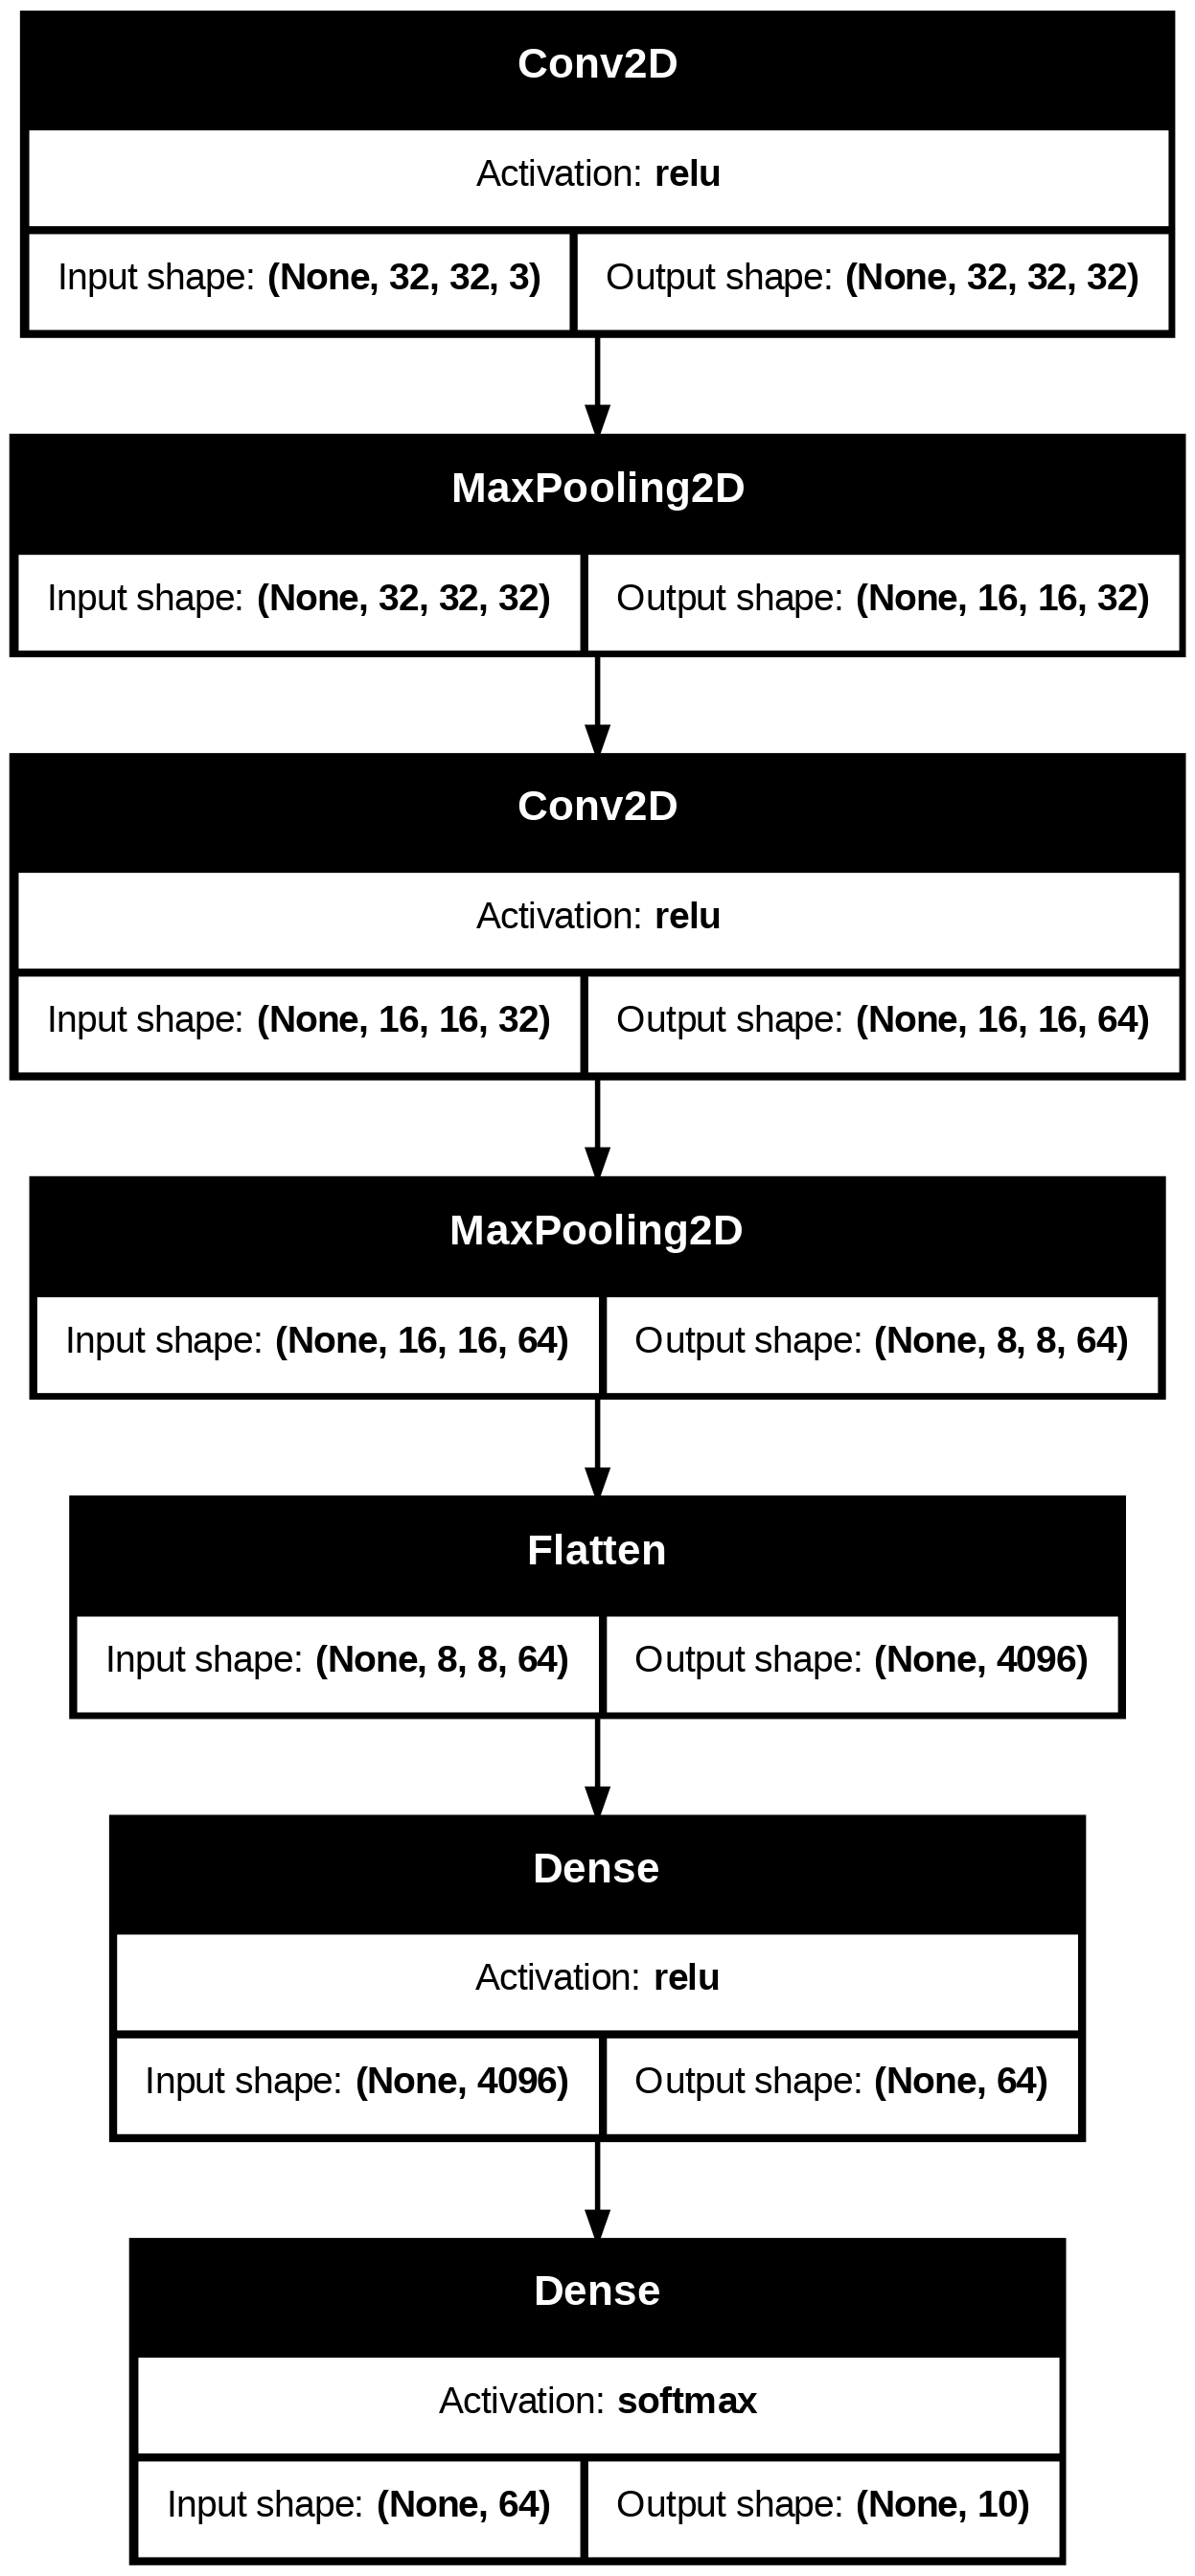

In [47]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),l2_penalty=0.002):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu",kernel_regularizer=l2(l2_penalty)))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu",kernel_regularizer=l2(l2_penalty)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, kernel_regularizer=l2(l2_penalty), activation='relu'))
  model.add(Dense(10, kernel_regularizer=l2(l2_penalty), activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
500/500 - 7s - 14ms/step - accuracy: 0.3712 - loss: 2.0866 - val_accuracy: 0.4822 - val_loss: 1.7630
Epoch 2/40
500/500 - 2s - 3ms/step - accuracy: 0.5234 - loss: 1.6261 - val_accuracy: 0.5663 - val_loss: 1.4976
Epoch 3/40
500/500 - 2s - 3ms/step - accuracy: 0.5838 - loss: 1.4385 - val_accuracy: 0.5993 - val_loss: 1.3865
Epoch 4/40
500/500 - 2s - 3ms/step - accuracy: 0.6203 - loss: 1.3273 - val_accuracy: 0.6170 - val_loss: 1.3406
Epoch 5/40
500/500 - 2s - 3ms/step - accuracy: 0.6512 - loss: 1.2497 - val_accuracy: 0.6459 - val_loss: 1.2553
Epoch 6/40
500/500 - 2s - 3ms/step - accuracy: 0.6699 - loss: 1.1965 - val_accuracy: 0.6603 - val_loss: 1.2271
Epoch 7/40
500/500 - 2s - 3ms/step - accuracy: 0.6830 - loss: 1.1653 - val_accuracy: 0.6283 - val_loss: 1.3093
Epoch 8/40
500/500 - 2s - 3ms/step - accuracy: 0.6930 - loss: 1.1433 - val_accuracy: 0.6720 - val_loss: 1.2211
Epoch 9/40
500/500 - 2s - 3ms/step - accuracy: 0.7062 - loss: 1.1181 - val_accuracy: 0.6795 - val_loss: 1.2190


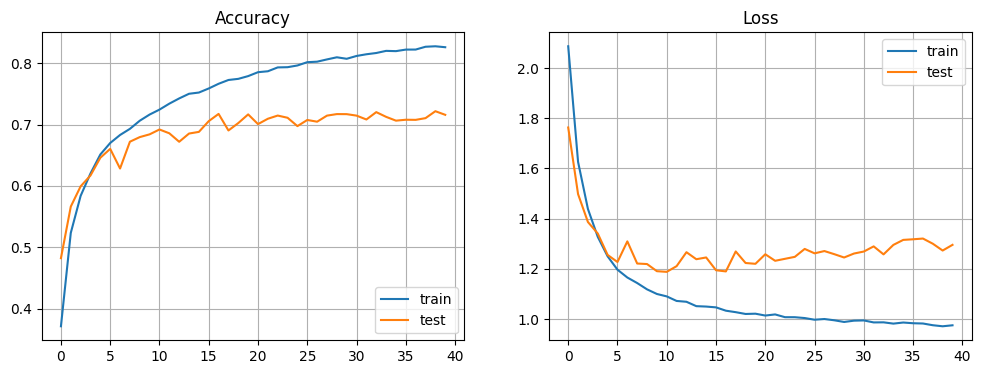

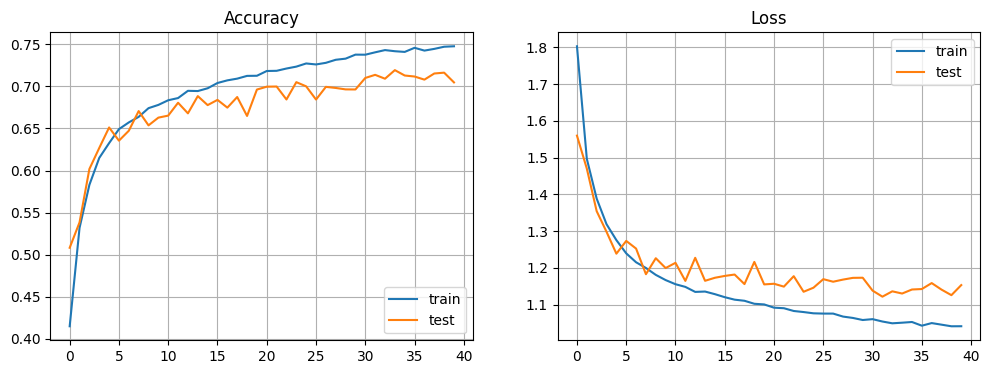

In [48]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model()
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

## Batch Normalization

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_120 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_121 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,890 (1.08 MB)

 Trainable params: 282,570 (1.08 MB)

 Non-trainable params: 320 (1.25 KB)

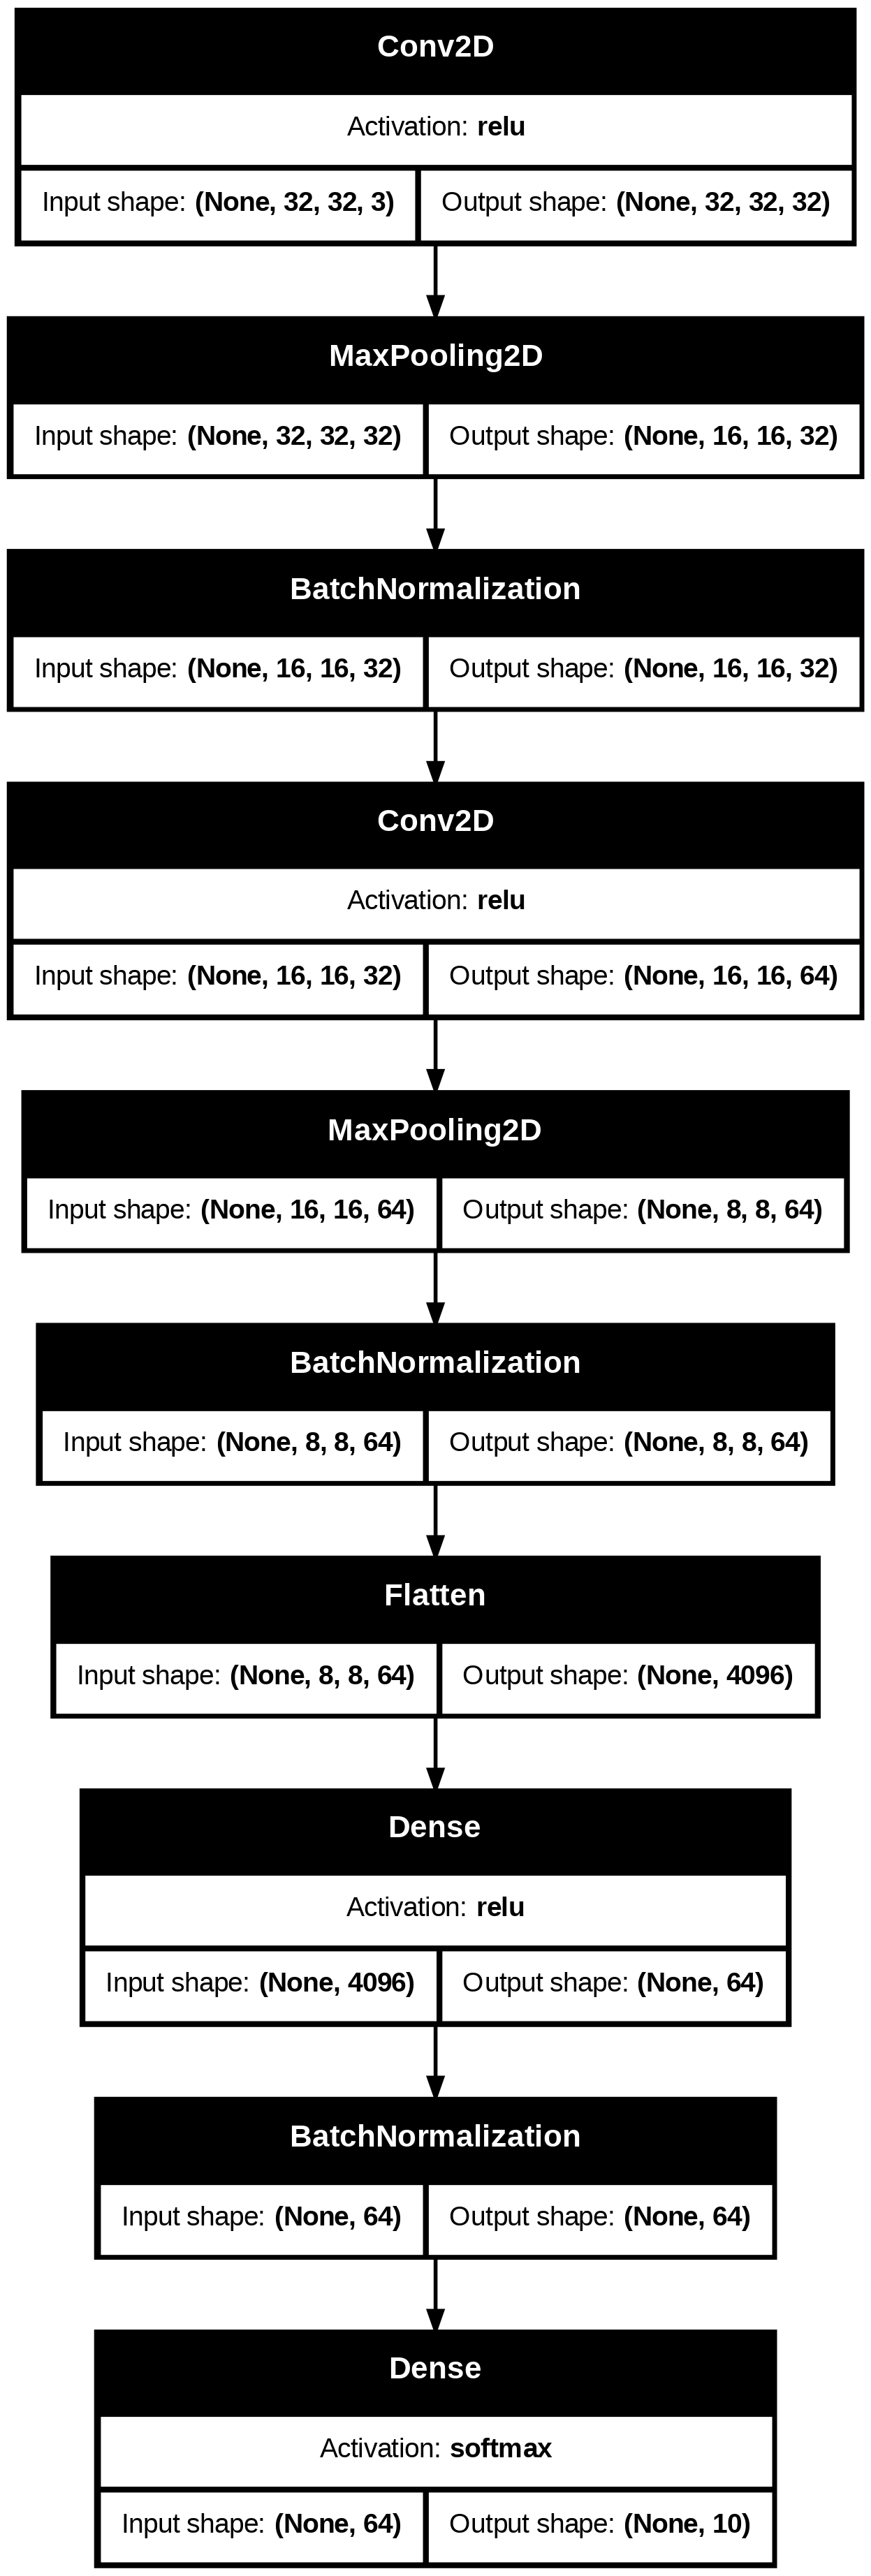

In [49]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The highest training accuracy was 0.9999 obtained in epoch 40
The final training accuracy was 0.9999
The highest validation accuracy was 0.7145 obtained in epoch 39
The final validation accuracy was 0.7138
The lowest training loss was 0.0026 obtained in epoch 40
The final training loss was 0.0026
The lowest validation loss was 0.9940 obtained in epoch 5
The final validation loss was 2.0052
The highest training accuracy was 0.9896 obtained in epoch 37
The final training accuracy was 0.9885
The highest validation accuracy was 0.7087 obtained in epoch 19
The final validation accuracy was 0.7074
The lowest training loss was 0.0324 obtained in epoch 37
The final training loss was 0.0348
The lowest validation loss was 0.8892 obtained in epoch 3
The final validation loss was 2.0107


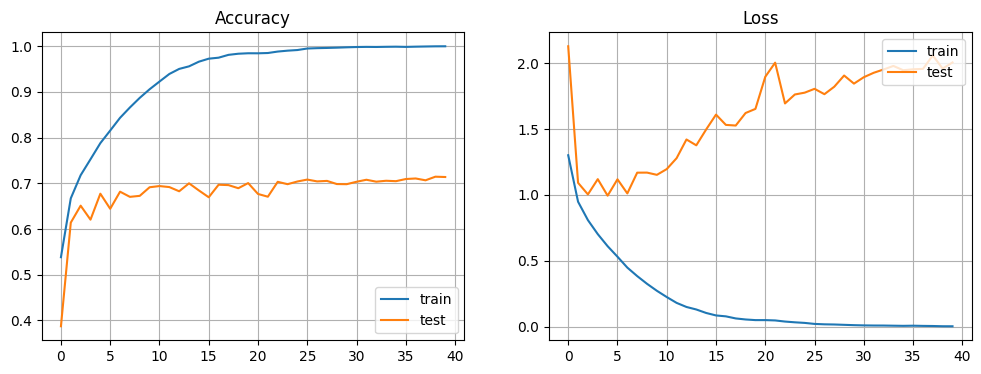

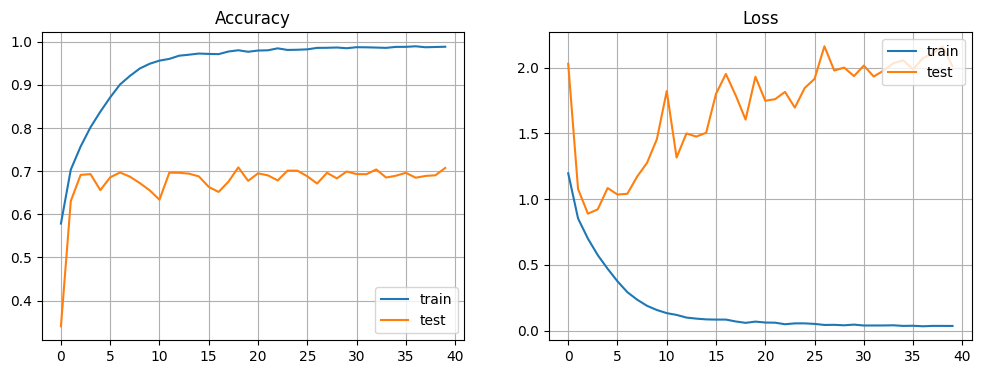

In [50]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model()
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 0,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

## Dropout

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_126 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_127 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

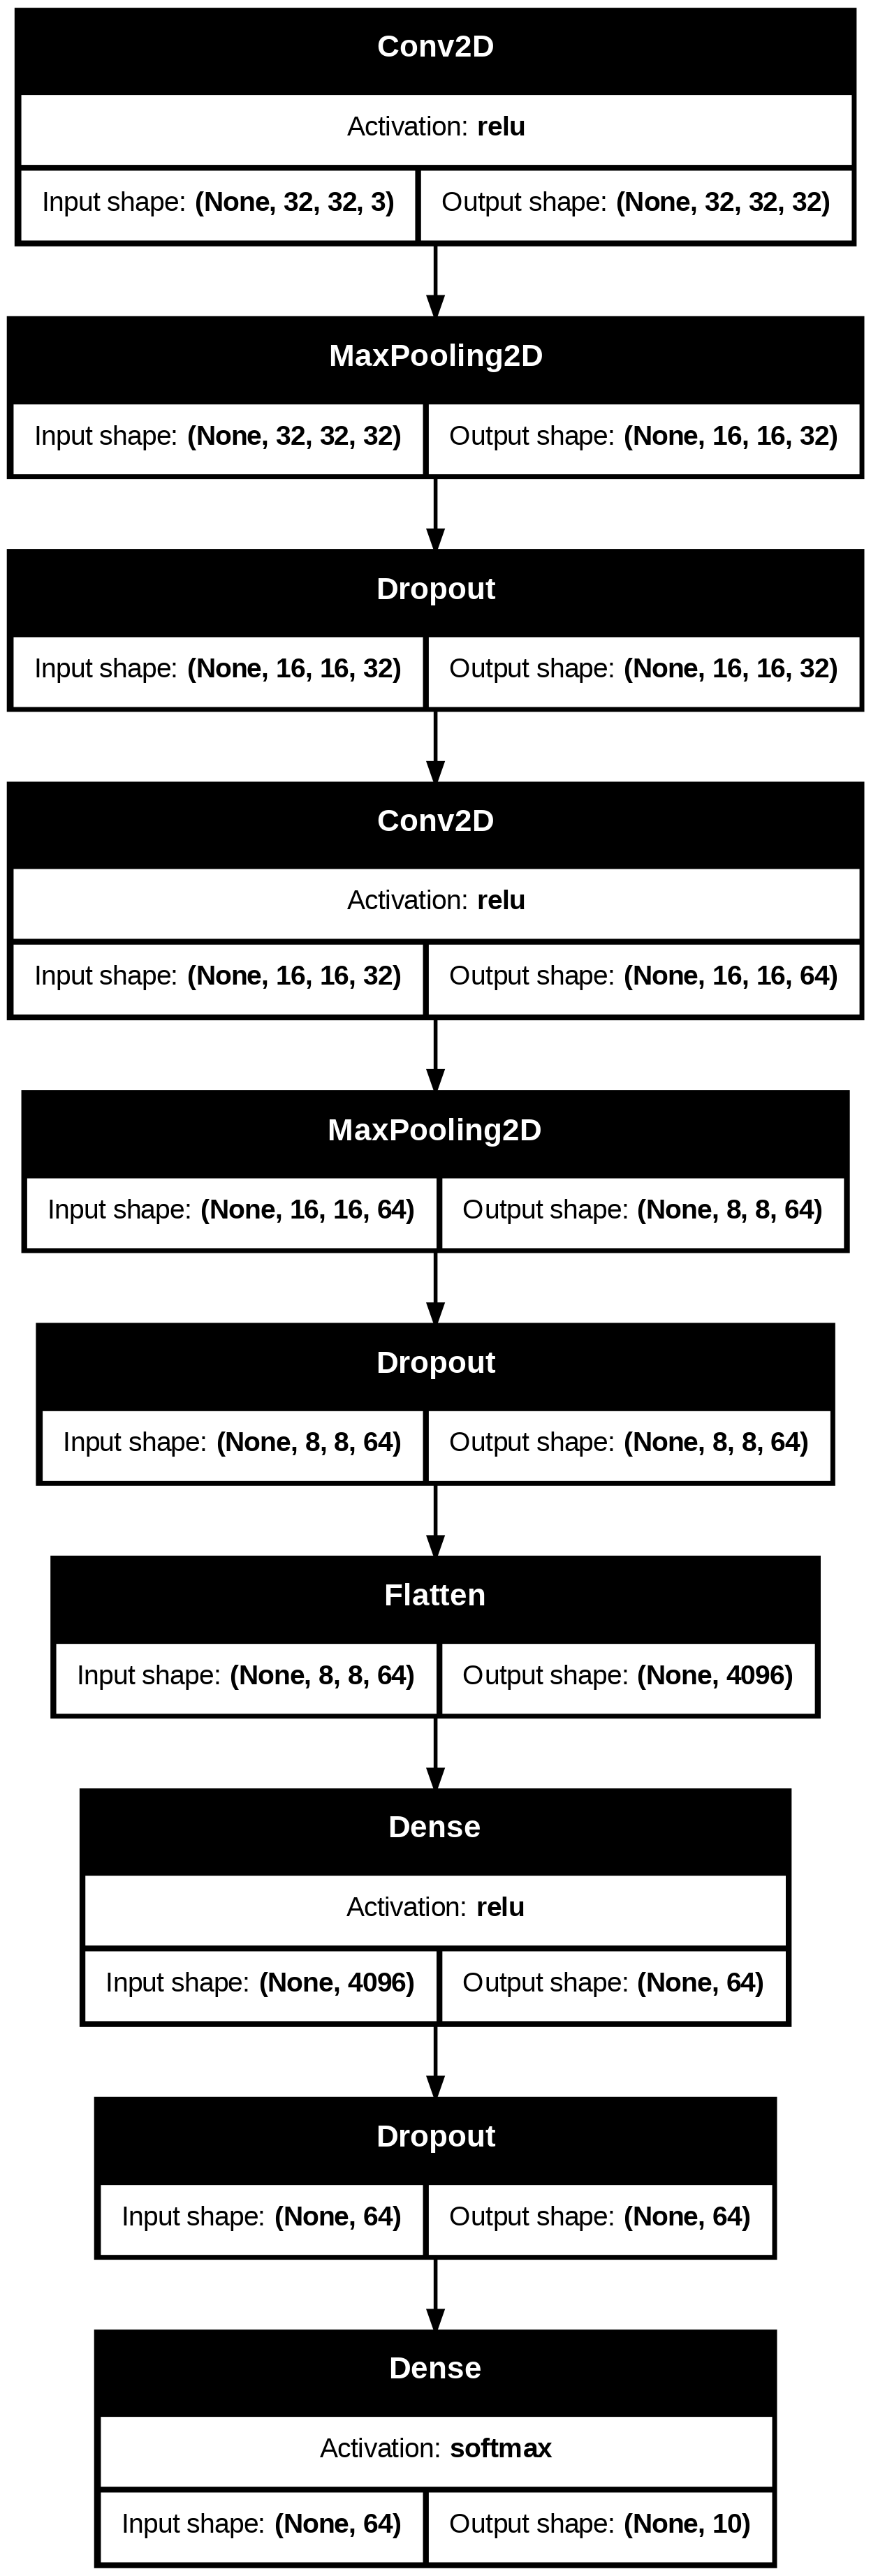

In [51]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dropout_rate = 0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
500/500 - 7s - 14ms/step - accuracy: 0.2916 - loss: 1.9358 - val_accuracy: 0.4387 - val_loss: 1.5946
Epoch 2/200
500/500 - 2s - 3ms/step - accuracy: 0.4347 - loss: 1.5584 - val_accuracy: 0.5022 - val_loss: 1.4004
Epoch 3/200
500/500 - 2s - 3ms/step - accuracy: 0.4876 - loss: 1.4192 - val_accuracy: 0.5414 - val_loss: 1.2748
Epoch 4/200
500/500 - 2s - 3ms/step - accuracy: 0.5213 - loss: 1.3275 - val_accuracy: 0.5657 - val_loss: 1.2453
Epoch 5/200
500/500 - 2s - 3ms/step - accuracy: 0.5522 - loss: 1.2516 - val_accuracy: 0.6216 - val_loss: 1.1066
Epoch 6/200
500/500 - 2s - 3ms/step - accuracy: 0.5777 - loss: 1.1875 - val_accuracy: 0.6260 - val_loss: 1.0869
Epoch 7/200
500/500 - 2s - 3ms/step - accuracy: 0.5935 - loss: 1.1394 - val_accuracy: 0.6339 - val_loss: 1.0380
Epoch 8/200
500/500 - 2s - 3ms/step - accuracy: 0.6095 - loss: 1.0937 - val_accuracy: 0.6301 - val_loss: 1.0506
Epoch 9/200
500/500 - 2s - 3ms/step - accuracy: 0.6242 - loss: 1.0671 - val_accuracy: 0.6597 - val_loss

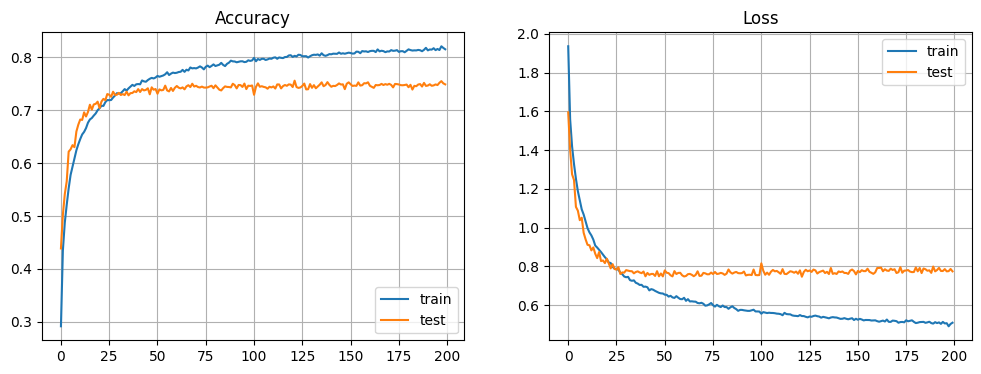

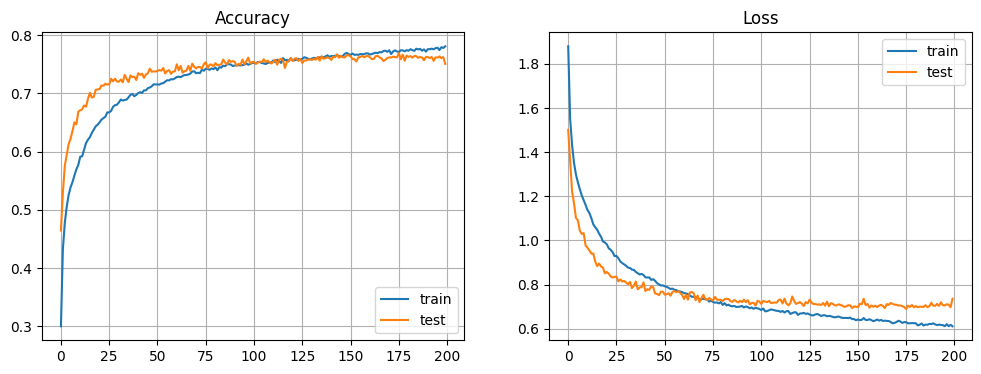

In [52]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model(dropout_rate = 0.3)
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  200,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

Epoch 1/80
500/500 - 6s - 12ms/step - accuracy: 0.2128 - loss: 2.1070 - val_accuracy: 0.3584 - val_loss: 1.8716
Epoch 2/80
500/500 - 2s - 3ms/step - accuracy: 0.3347 - loss: 1.8117 - val_accuracy: 0.4111 - val_loss: 1.6915
Epoch 3/80
500/500 - 2s - 3ms/step - accuracy: 0.3879 - loss: 1.6751 - val_accuracy: 0.4659 - val_loss: 1.5093
Epoch 4/80
500/500 - 2s - 3ms/step - accuracy: 0.4140 - loss: 1.6073 - val_accuracy: 0.4806 - val_loss: 1.4708
Epoch 5/80
500/500 - 2s - 3ms/step - accuracy: 0.4368 - loss: 1.5478 - val_accuracy: 0.4983 - val_loss: 1.4062
Epoch 6/80
500/500 - 2s - 3ms/step - accuracy: 0.4570 - loss: 1.4973 - val_accuracy: 0.5087 - val_loss: 1.4163
Epoch 7/80
500/500 - 2s - 3ms/step - accuracy: 0.4706 - loss: 1.4559 - val_accuracy: 0.5543 - val_loss: 1.2884
Epoch 8/80
500/500 - 2s - 3ms/step - accuracy: 0.4845 - loss: 1.4252 - val_accuracy: 0.5627 - val_loss: 1.2737
Epoch 9/80
500/500 - 2s - 3ms/step - accuracy: 0.4984 - loss: 1.3896 - val_accuracy: 0.5530 - val_loss: 1.2817


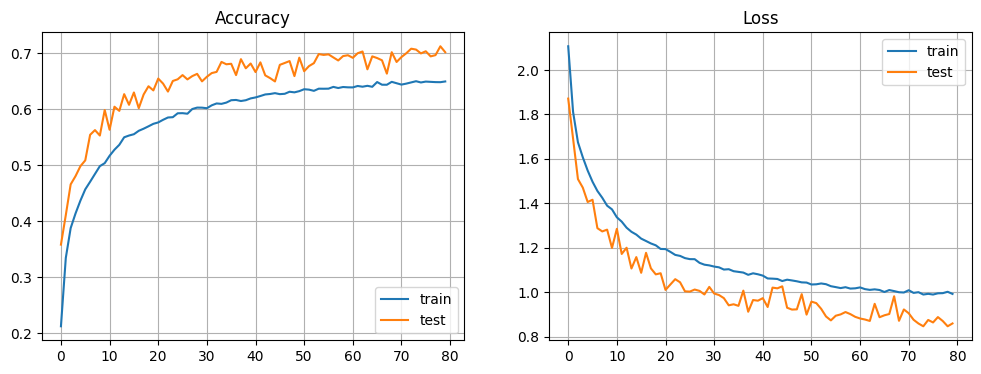

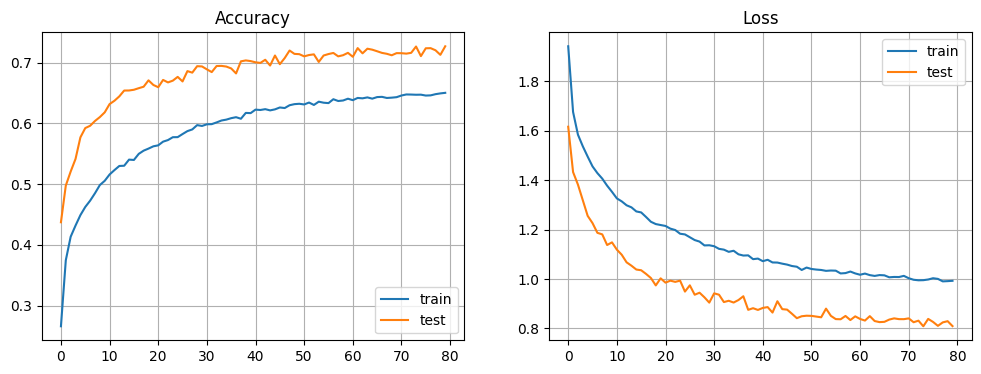

In [53]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model()
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  80,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

## Learning-Rate Decay

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_136 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_91 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_137 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

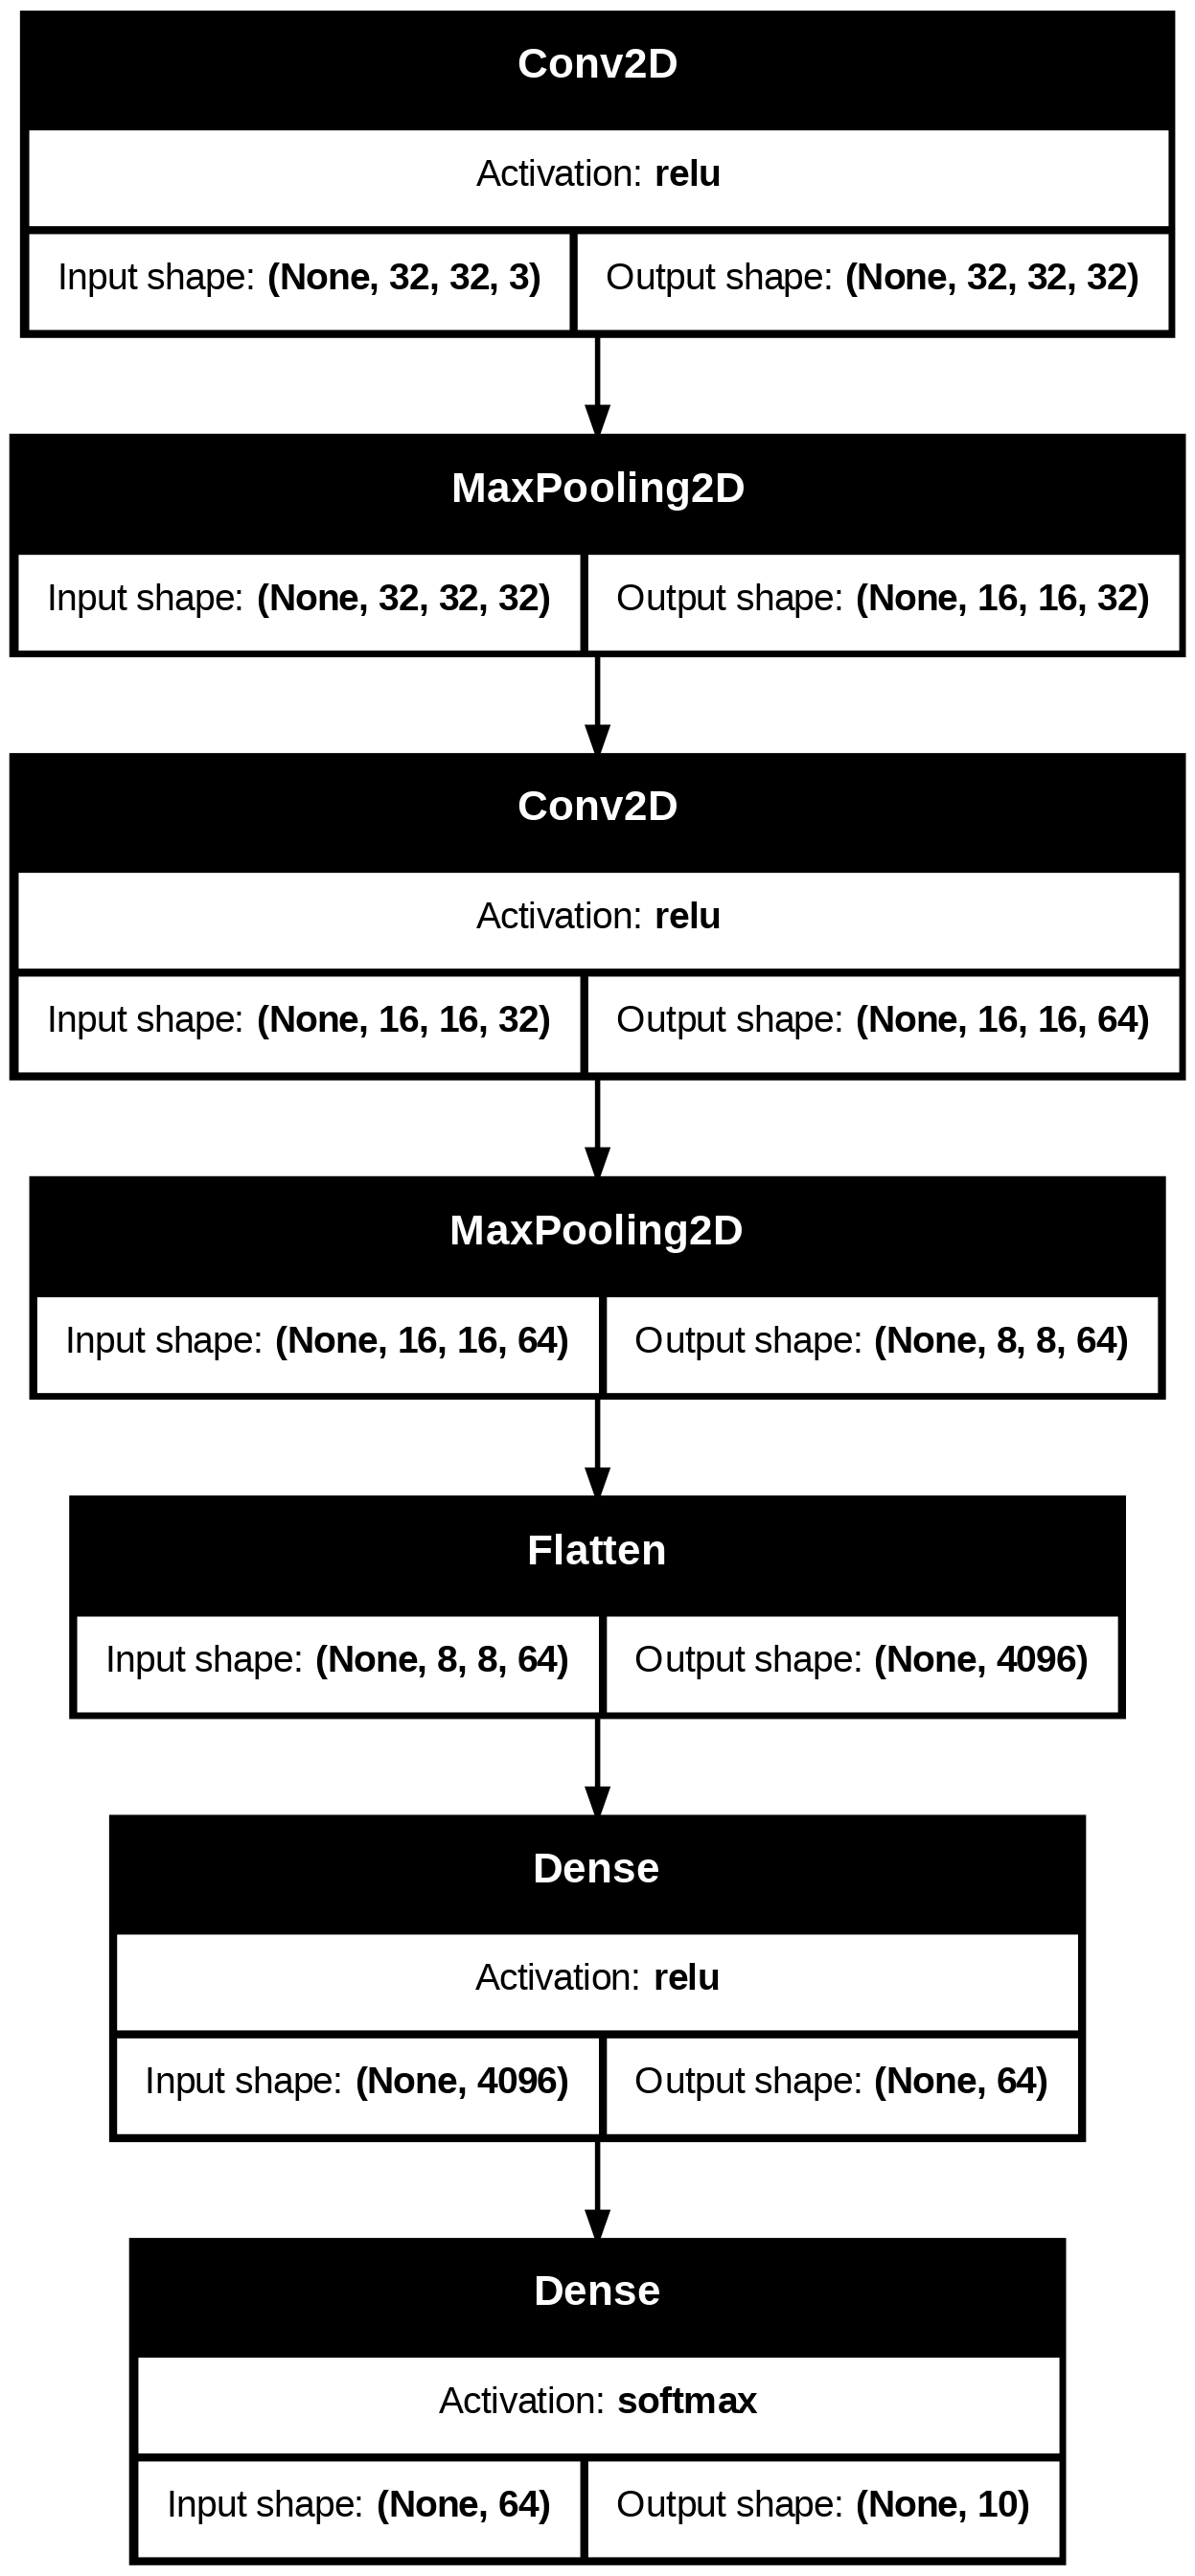

In [54]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

In [55]:
BATCH_SIZE = 100
STEPS_PER_EPOCH = len(y_train)//BATCH_SIZE
n = 1
decay_steps=STEPS_PER_EPOCH*n
decay_rate = 0.9
ratio = decay_rate**(40//n)
print('decay_steps =',decay_steps,'ratio =', 1/ratio)

lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
  0.02,
  decay_steps=decay_steps,
  decay_rate=decay_rate,
  staircase=True)

decay_steps = 500 ratio = 67.6549570118537


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
500/500 - 6s - 12ms/step - accuracy: 0.4111 - loss: 1.6274 - val_accuracy: 0.5213 - val_loss: 1.3169
Epoch 2/40
500/500 - 2s - 3ms/step - accuracy: 0.6002 - loss: 1.1332 - val_accuracy: 0.6195 - val_loss: 1.0934
Epoch 3/40
500/500 - 2s - 3ms/step - accuracy: 0.6555 - loss: 0.9762 - val_accuracy: 0.6402 - val_loss: 1.0091
Epoch 4/40
500/500 - 2s - 3ms/step - accuracy: 0.6931 - loss: 0.8804 - val_accuracy: 0.6741 - val_loss: 0.9346
Epoch 5/40
500/500 - 2s - 3ms/step - accuracy: 0.7150 - loss: 0.8181 - val_accuracy: 0.6803 - val_loss: 0.9202
Epoch 6/40
500/500 - 2s - 3ms/step - accuracy: 0.7352 - loss: 0.7632 - val_accuracy: 0.6773 - val_loss: 0.9222
Epoch 7/40
500/500 - 2s - 3ms/step - accuracy: 0.7495 - loss: 0.7220 - val_accuracy: 0.6872 - val_loss: 0.9046
Epoch 8/40
500/500 - 2s - 3ms/step - accuracy: 0.7608 - loss: 0.6877 - val_accuracy: 0.6943 - val_loss: 0.8960
Epoch 9/40
500/500 - 2s - 3ms/step - accuracy: 0.7719 - loss: 0.6576 - val_accuracy: 0.6987 - val_loss: 0.8970


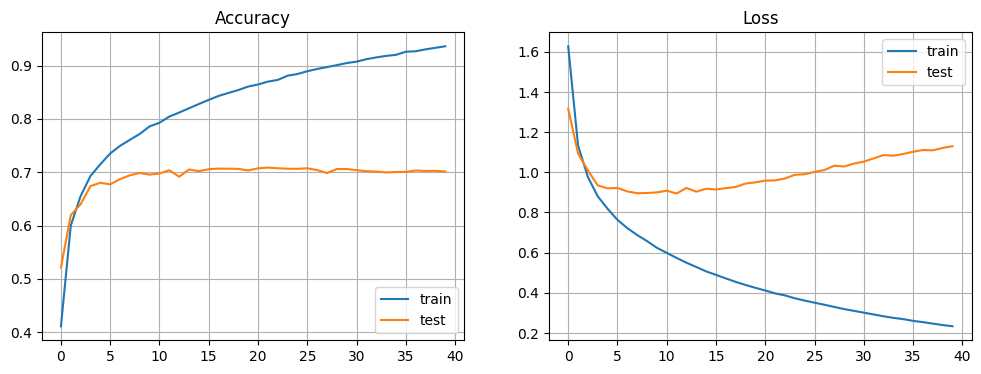

In [56]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9,learning_rate=lr_schedule)]:
  model = cnn_model()
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

## Data Augmentation

In [57]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

In [58]:
y_train.shape

(100000, 1)

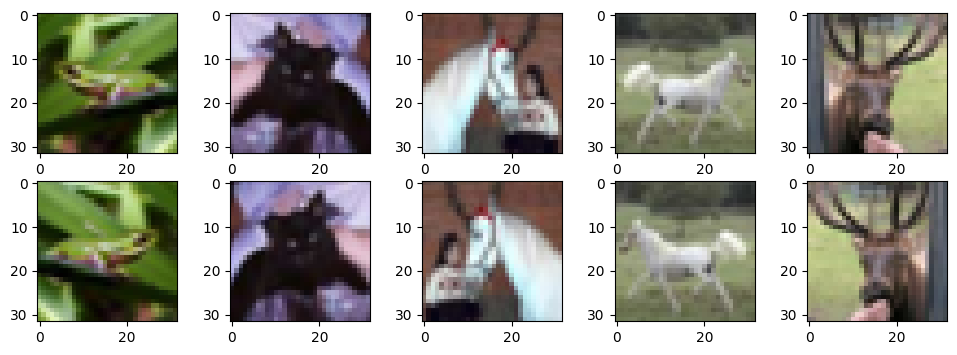

In [59]:
n0 = x_train.shape[0]//2
sel = np.random.randint(0,n0,size = 5)
fig, ax = plt.subplots(nrows=2,ncols=len(sel), figsize=(12,4))
for i,s in enumerate(sel):
  ax[0,i].imshow(x_train[s])
  ax[1,i].imshow(x_train[s+n0])

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_140 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_95 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_141 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_96 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_36 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

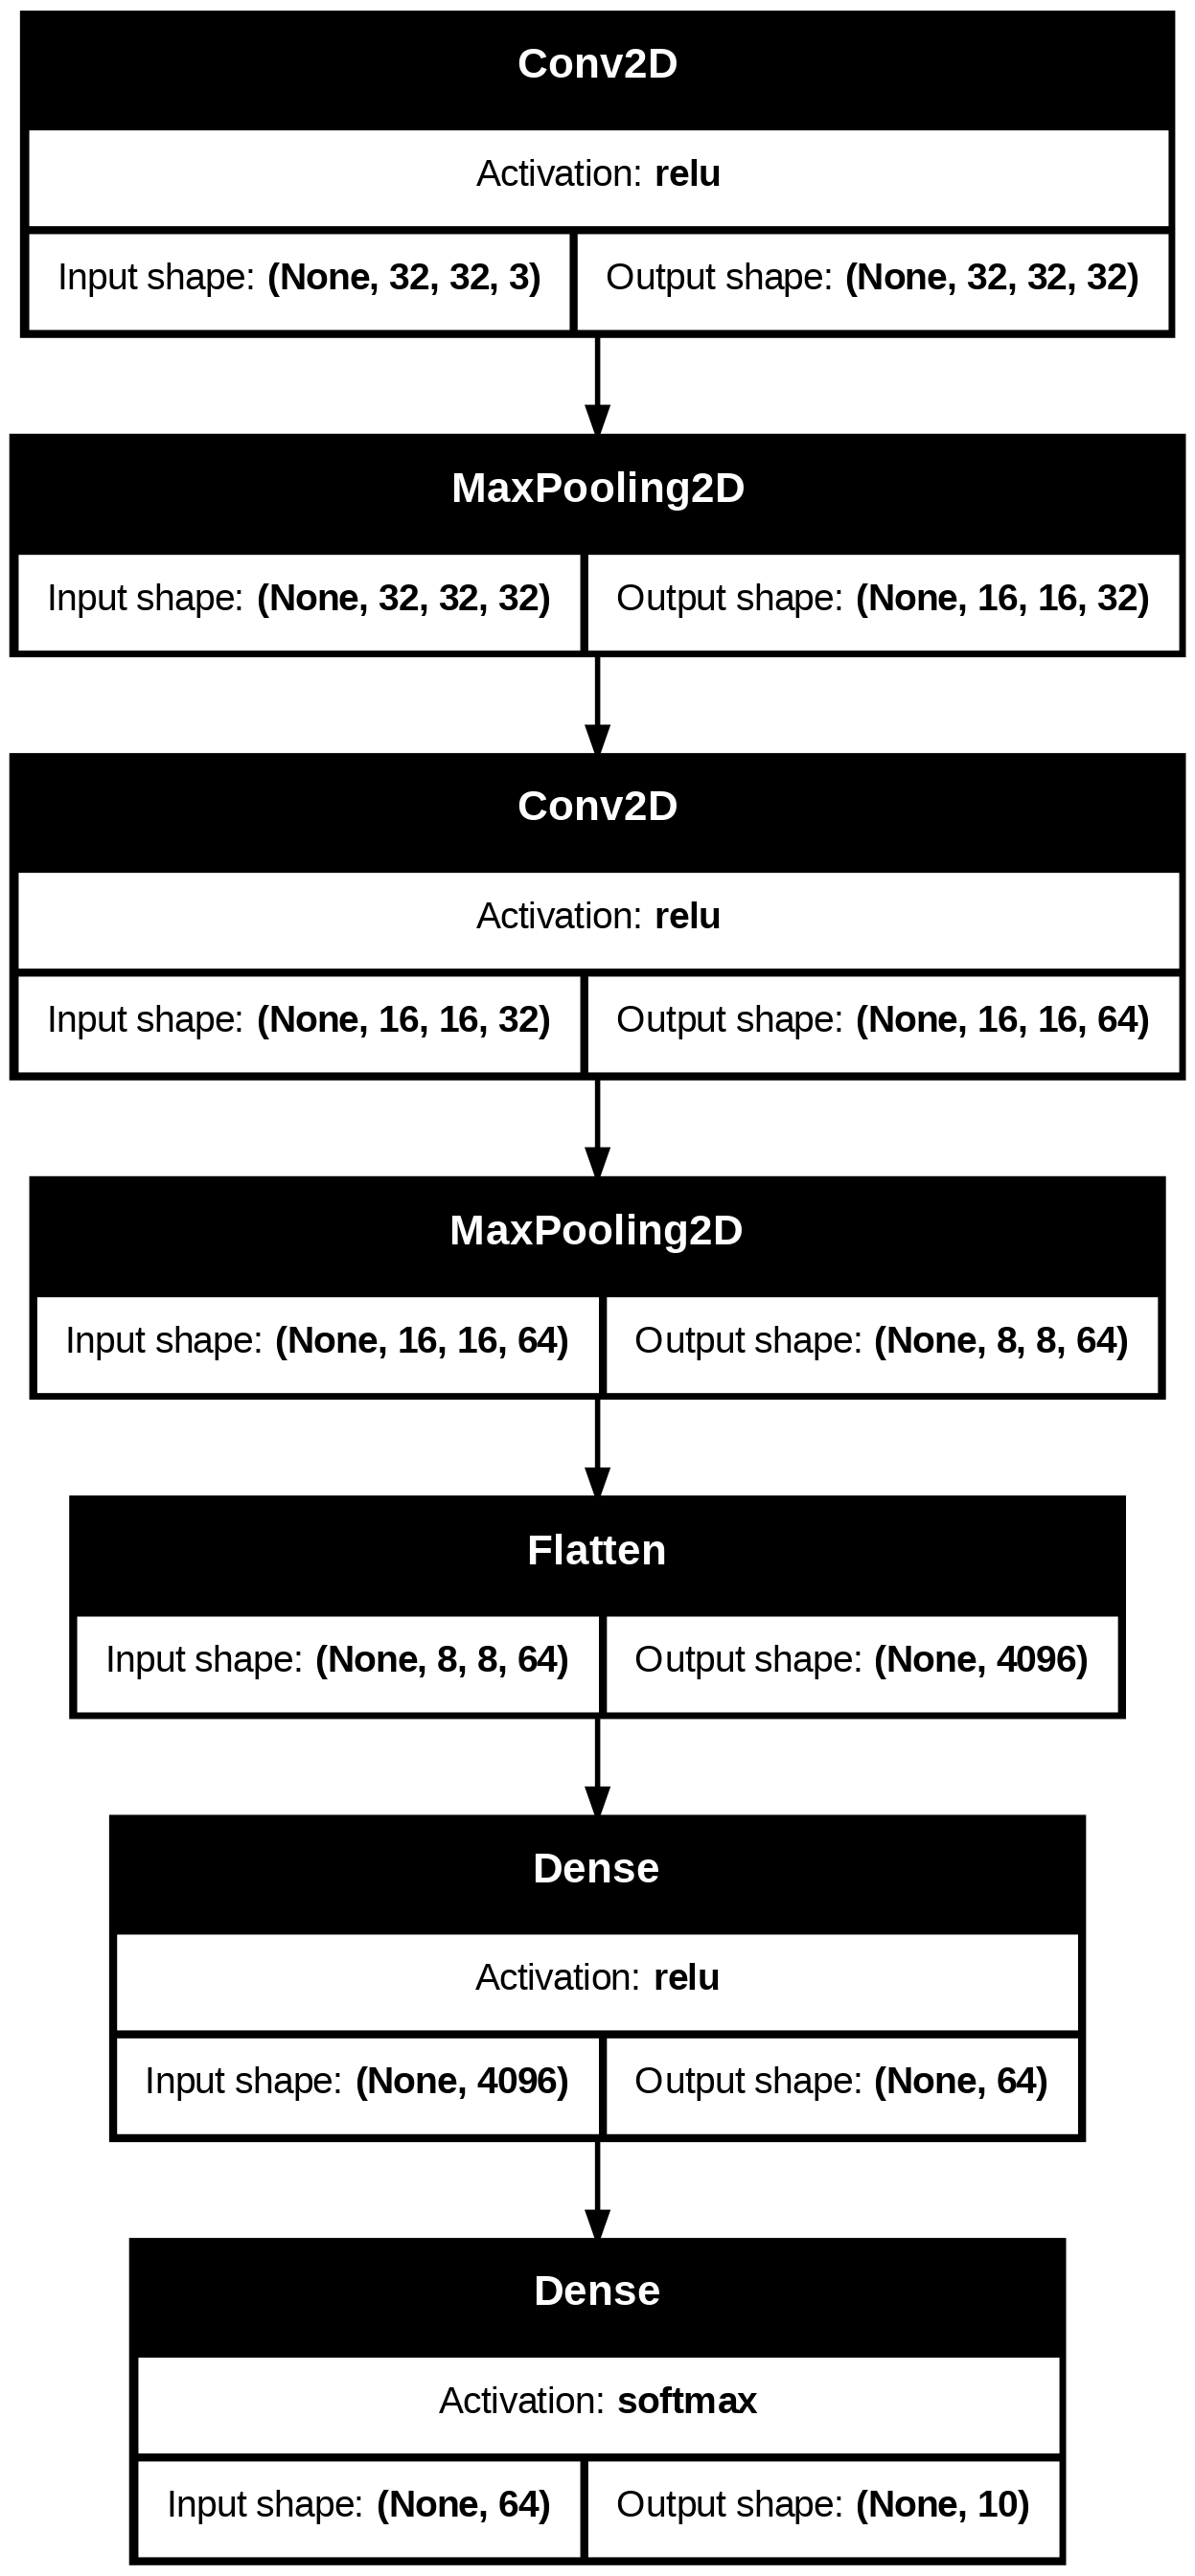

In [60]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
1000/1000 - 6s - 6ms/step - accuracy: 0.4532 - loss: 1.5244 - val_accuracy: 0.5747 - val_loss: 1.2016
Epoch 2/40
1000/1000 - 3s - 3ms/step - accuracy: 0.6288 - loss: 1.0557 - val_accuracy: 0.6589 - val_loss: 0.9745
Epoch 3/40
1000/1000 - 3s - 3ms/step - accuracy: 0.6887 - loss: 0.8877 - val_accuracy: 0.6959 - val_loss: 0.8703
Epoch 4/40
1000/1000 - 3s - 3ms/step - accuracy: 0.7240 - loss: 0.7874 - val_accuracy: 0.7087 - val_loss: 0.8531
Epoch 5/40
1000/1000 - 3s - 3ms/step - accuracy: 0.7519 - loss: 0.7115 - val_accuracy: 0.7271 - val_loss: 0.8014
Epoch 6/40
1000/1000 - 3s - 3ms/step - accuracy: 0.7763 - loss: 0.6363 - val_accuracy: 0.7333 - val_loss: 0.7888
Epoch 7/40
1000/1000 - 3s - 3ms/step - accuracy: 0.7991 - loss: 0.5723 - val_accuracy: 0.7387 - val_loss: 0.7965
Epoch 8/40
1000/1000 - 3s - 3ms/step - accuracy: 0.8191 - loss: 0.5180 - val_accuracy: 0.7356 - val_loss: 0.8136
Epoch 9/40
1000/1000 - 3s - 3ms/step - accuracy: 0.8373 - loss: 0.4653 - val_accuracy: 0.7412 - 

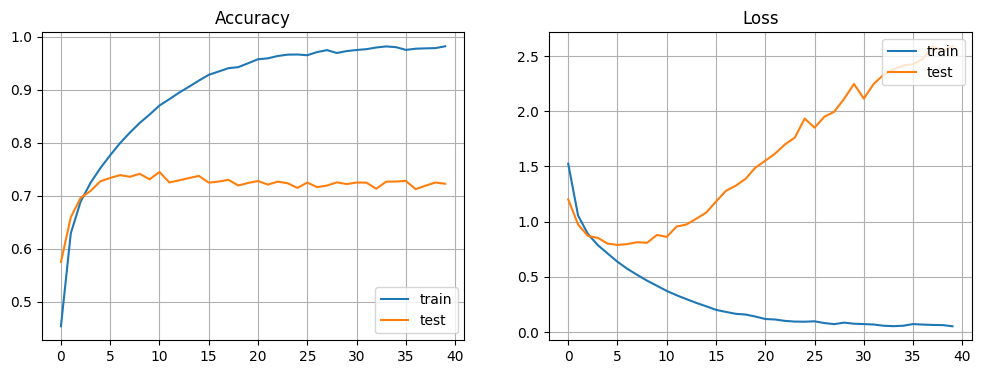

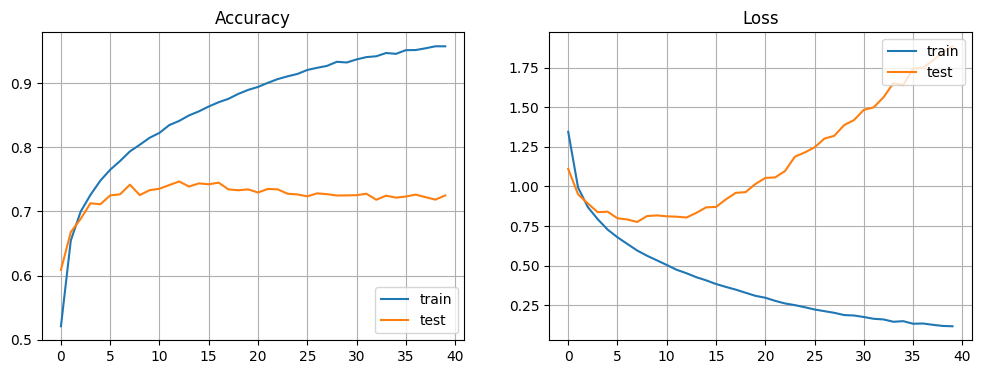

In [61]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model()
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

**Data Augmentation at Prediction Time**

In [62]:
pred1.shape

(10000, 10)

In [63]:
pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

Model accuracy on test set: 0.7250
Model accuracy on mirrored test set: 0.7215
Model accuracy on combined original and mirrored test set: 0.7471


## Data Augmentation with Back-to-Back Convolutions

In [64]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

In [65]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
500/500 - 9s - 17ms/step - accuracy: 0.5117 - loss: 1.3688 - val_accuracy: 0.6100 - val_loss: 1.1115
Epoch 2/20
500/500 - 2s - 5ms/step - accuracy: 0.6714 - loss: 0.9369 - val_accuracy: 0.6825 - val_loss: 0.9147
Epoch 3/20
500/500 - 2s - 5ms/step - accuracy: 0.7285 - loss: 0.7820 - val_accuracy: 0.7346 - val_loss: 0.7638
Epoch 4/20
500/500 - 2s - 5ms/step - accuracy: 0.7654 - loss: 0.6757 - val_accuracy: 0.7531 - val_loss: 0.7250
Epoch 5/20
500/500 - 2s - 5ms/step - accuracy: 0.7923 - loss: 0.5984 - val_accuracy: 0.7601 - val_loss: 0.6970
Epoch 6/20
500/500 - 2s - 5ms/step - accuracy: 0.8140 - loss: 0.5341 - val_accuracy: 0.7762 - val_loss: 0.6651
Epoch 7/20
500/500 - 2s - 5ms/step - accuracy: 0.8323 - loss: 0.4812 - val_accuracy: 0.7810 - val_loss: 0.6520
Epoch 8/20
500/500 - 2s - 5ms/step - accuracy: 0.8470 - loss: 0.4354 - val_accuracy: 0.7715 - val_loss: 0.7053
Epoch 9/20
500/500 - 2s - 5ms/step - accuracy: 0.8630 - loss: 0.3936 - val_accuracy: 0.7853 - val_loss: 0.6648


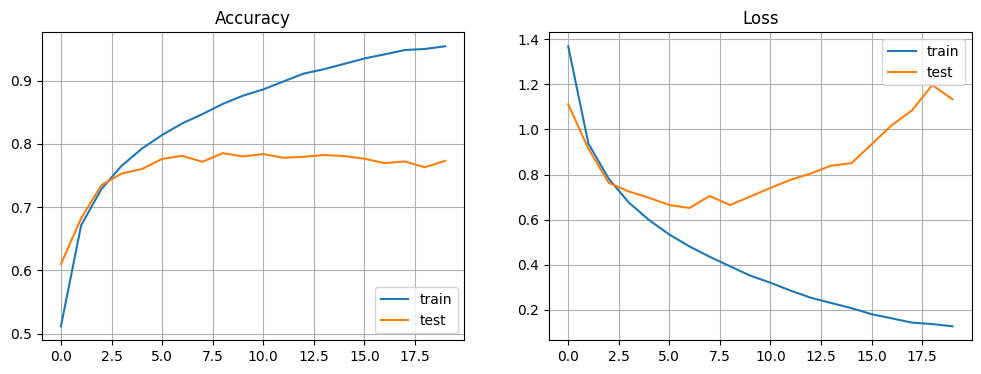

In [66]:
opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  20,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

In [67]:
pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

Model accuracy on test set: 0.7732
Model accuracy on mirrored test set: 0.7735
Model accuracy on combined original and mirrored test set: 0.7974


## Data Augmentation, Back-to-Back Convolutions, and Dropout

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
500/500 - 9s - 18ms/step - accuracy: 0.3364 - loss: 1.7851 - val_accuracy: 0.5156 - val_loss: 1.3327
Epoch 2/40
500/500 - 2s - 5ms/step - accuracy: 0.4894 - loss: 1.4082 - val_accuracy: 0.5842 - val_loss: 1.1697
Epoch 3/40
500/500 - 2s - 5ms/step - accuracy: 0.5473 - loss: 1.2605 - val_accuracy: 0.6427 - val_loss: 1.0024
Epoch 4/40
500/500 - 2s - 5ms/step - accuracy: 0.5857 - loss: 1.1693 - val_accuracy: 0.6712 - val_loss: 0.9178
Epoch 5/40
500/500 - 2s - 5ms/step - accuracy: 0.6057 - loss: 1.1107 - val_accuracy: 0.6634 - val_loss: 0.9487
Epoch 6/40
500/500 - 2s - 5ms/step - accuracy: 0.6286 - loss: 1.0531 - val_accuracy: 0.7006 - val_loss: 0.8485
Epoch 7/40
500/500 - 2s - 5ms/step - accuracy: 0.6420 - loss: 1.0210 - val_accuracy: 0.7052 - val_loss: 0.8316
Epoch 8/40
500/500 - 2s - 5ms/step - accuracy: 0.6557 - loss: 0.9860 - val_accuracy: 0.7364 - val_loss: 0.7516
Epoch 9/40
500/500 - 2s - 5ms/step - accuracy: 0.6648 - loss: 0.9548 - val_accuracy: 0.7402 - val_loss: 0.7419


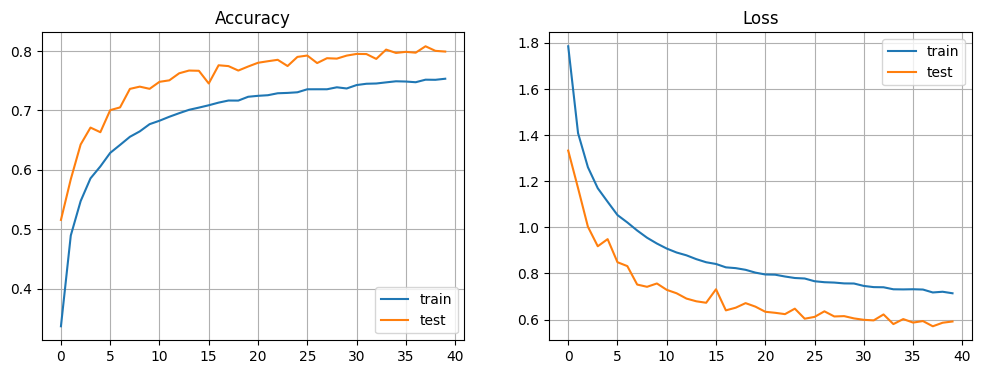

In [68]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

## Data Augmentation with Dropout and Batch Normalization

In [69]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_154 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_155 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_105               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_156 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_157 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_106               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_41 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,066 (1.26 MB)

 Trainable params: 328,746 (1.25 MB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/60
500/500 - 10s - 20ms/step - accuracy: 0.5525 - loss: 1.2695 - val_accuracy: 0.1388 - val_loss: 4.5212
Epoch 2/60
500/500 - 3s - 5ms/step - accuracy: 0.7015 - loss: 0.8504 - val_accuracy: 0.7022 - val_loss: 0.8641
Epoch 3/60
500/500 - 3s - 5ms/step - accuracy: 0.7440 - loss: 0.7325 - val_accuracy: 0.7480 - val_loss: 0.7325
Epoch 4/60
500/500 - 3s - 5ms/step - accuracy: 0.7714 - loss: 0.6590 - val_accuracy: 0.7213 - val_loss: 0.8220
Epoch 5/60
500/500 - 3s - 5ms/step - accuracy: 0.7882 - loss: 0.6074 - val_accuracy: 0.7207 - val_loss: 0.8425
Epoch 6/60
500/500 - 2s - 5ms/step - accuracy: 0.8009 - loss: 0.5709 - val_accuracy: 0.7855 - val_loss: 0.6146
Epoch 7/60
500/500 - 3s - 5ms/step - accuracy: 0.8117 - loss: 0.5370 - val_accuracy: 0.8018 - val_loss: 0.5970
Epoch 8/60
500/500 - 3s - 5ms/step - accuracy: 0.8199 - loss: 0.5102 - val_accuracy: 0.7833 - val_loss: 0.6552
Epoch 9/60
500/500 - 3s - 5ms/step - accuracy: 0.8275 - loss: 0.4882 - val_accuracy: 0.7995 - val_loss: 0.5786

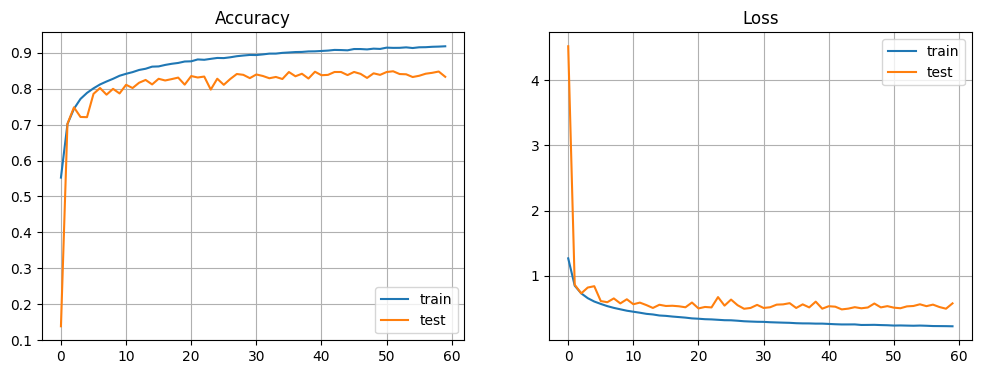

In [70]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model(dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  60,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

## Deeper Augmented CNN with Dropout and Batch Normalization

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_158 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_159 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_107               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_160 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_161 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_108               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_162 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_163 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_109               │ (None, 4, 4, 96)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_42 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,042 (1.16 MB)

 Trainable params: 303,530 (1.16 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
500/500 - 14s - 29ms/step - accuracy: 0.5176 - loss: 1.3626 - val_accuracy: 0.2732 - val_loss: 2.8371
Epoch 2/60
500/500 - 3s - 6ms/step - accuracy: 0.6897 - loss: 0.8806 - val_accuracy: 0.6911 - val_loss: 0.8965
Epoch 3/60
500/500 - 3s - 6ms/step - accuracy: 0.7412 - loss: 0.7390 - val_accuracy: 0.7442 - val_loss: 0.7413
Epoch 4/60
500/500 - 3s - 6ms/step - accuracy: 0.7733 - loss: 0.6528 - val_accuracy: 0.7905 - val_loss: 0.6005
Epoch 5/60
500/500 - 3s - 6ms/step - accuracy: 0.7945 - loss: 0.5928 - val_accuracy: 0.7739 - val_loss: 0.6712
Epoch 6/60
500/500 - 3s - 6ms/step - accuracy: 0.8077 - loss: 0.5560 - val_accuracy: 0.7787 - val_loss: 0.6462
Epoch 7/60
500/500 - 3s - 6ms/step - accuracy: 0.8219 - loss: 0.5118 - val_accuracy: 0.8183 - val_loss: 0.5271
Epoch 8/60
500/500 - 3s - 6ms/step - accuracy: 0.8310 - loss: 0.4880 - val_accuracy: 0.8161 - val_loss: 0.5527
Epoch 9/60
500/500 - 3s - 6ms/step - accuracy: 0.8413 - loss: 0.4588 - val_accuracy: 0.8118 - val_loss: 0.5494

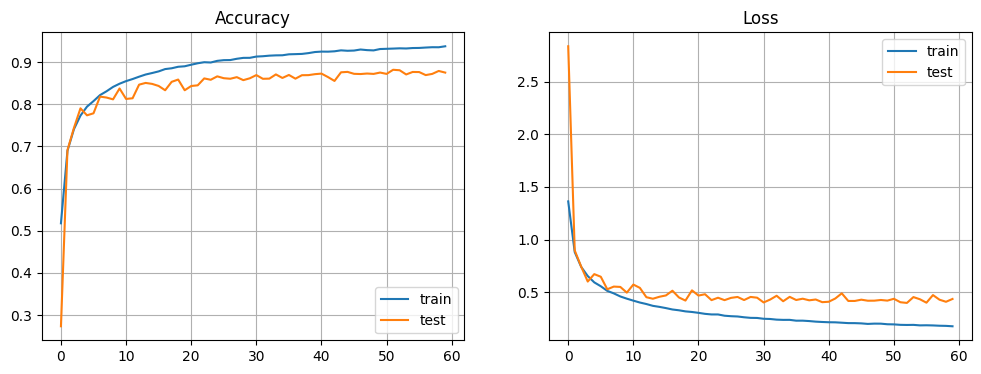

In [71]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,96),dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  60,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_164 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_165 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_110               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_166 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_167 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_111               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_168 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_169 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_112               │ (None, 4, 4, 96)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_170 (Conv2D)             │ (None, 4, 4, 128)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_171 (Conv2D)             │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_113               │ (None, 2, 2, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_43 (Flatten)            │ (None, 512)            │             

 Total params: 497,322 (1.90 MB)

 Trainable params: 496,554 (1.89 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
500/500 - 19s - 38ms/step - accuracy: 0.4793 - loss: 1.4627 - val_accuracy: 0.2441 - val_loss: 2.9607
Epoch 2/80
500/500 - 3s - 6ms/step - accuracy: 0.6753 - loss: 0.9216 - val_accuracy: 0.6429 - val_loss: 1.0419
Epoch 3/80
500/500 - 3s - 6ms/step - accuracy: 0.7423 - loss: 0.7403 - val_accuracy: 0.7418 - val_loss: 0.7452
Epoch 4/80
500/500 - 3s - 6ms/step - accuracy: 0.7778 - loss: 0.6410 - val_accuracy: 0.7423 - val_loss: 0.7777
Epoch 5/80
500/500 - 3s - 6ms/step - accuracy: 0.8033 - loss: 0.5734 - val_accuracy: 0.7831 - val_loss: 0.6462
Epoch 6/80
500/500 - 3s - 6ms/step - accuracy: 0.8190 - loss: 0.5239 - val_accuracy: 0.8092 - val_loss: 0.5777
Epoch 7/80
500/500 - 3s - 6ms/step - accuracy: 0.8328 - loss: 0.4830 - val_accuracy: 0.8101 - val_loss: 0.5677
Epoch 8/80
500/500 - 3s - 6ms/step - accuracy: 0.8444 - loss: 0.4525 - val_accuracy: 0.8144 - val_loss: 0.5529
Epoch 9/80
500/500 - 3s - 6ms/step - accuracy: 0.8545 - loss: 0.4235 - val_accuracy: 0.8054 - val_loss: 0.5967

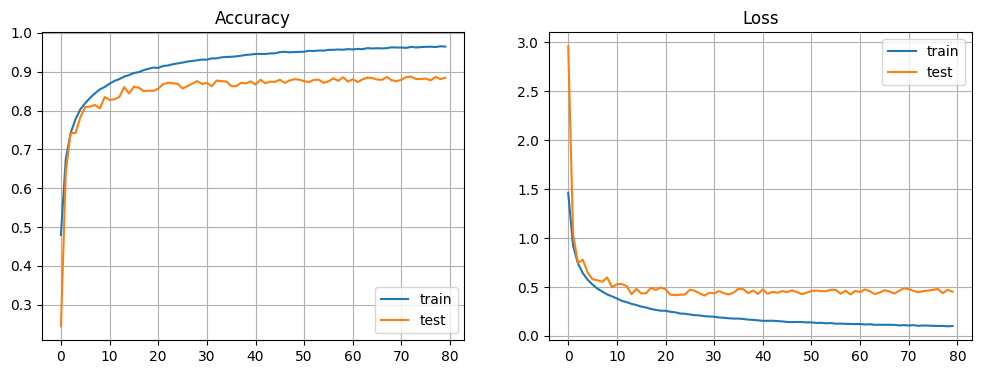

In [72]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())

  model.add(Dense(64, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,96,128), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  80,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

Epoch 1/80
500/500 - 3s - 7ms/step - accuracy: 0.9671 - loss: 0.0955 - val_accuracy: 0.8818 - val_loss: 0.4661
Epoch 2/80
500/500 - 3s - 6ms/step - accuracy: 0.9654 - loss: 0.0978 - val_accuracy: 0.8831 - val_loss: 0.4570
Epoch 3/80
500/500 - 3s - 6ms/step - accuracy: 0.9668 - loss: 0.0954 - val_accuracy: 0.8860 - val_loss: 0.4630
Epoch 4/80
500/500 - 3s - 6ms/step - accuracy: 0.9660 - loss: 0.0951 - val_accuracy: 0.8744 - val_loss: 0.4906
Epoch 5/80
500/500 - 3s - 6ms/step - accuracy: 0.9670 - loss: 0.0949 - val_accuracy: 0.8862 - val_loss: 0.4472
Epoch 6/80
500/500 - 3s - 6ms/step - accuracy: 0.9671 - loss: 0.0930 - val_accuracy: 0.8781 - val_loss: 0.4857
Epoch 7/80
500/500 - 3s - 6ms/step - accuracy: 0.9668 - loss: 0.0949 - val_accuracy: 0.8793 - val_loss: 0.4682
Epoch 8/80
500/500 - 3s - 6ms/step - accuracy: 0.9674 - loss: 0.0933 - val_accuracy: 0.8893 - val_loss: 0.4442
Epoch 9/80
500/500 - 3s - 6ms/step - accuracy: 0.9677 - loss: 0.0930 - val_accuracy: 0.8879 - val_loss: 0.4496
E

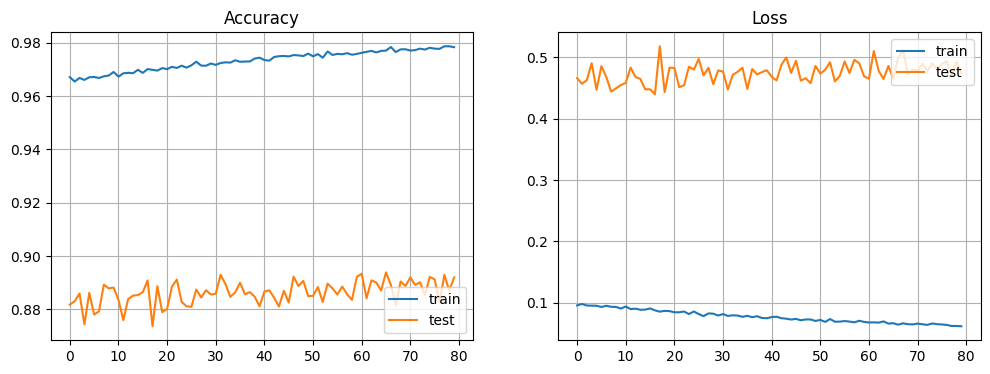

In [73]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

def cnn_model(input_shape=(32,32,3), conv_units = (32,64), dense_units = (64,), dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  for d in dense_units:
    model.add(Dense(d, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

#opt = tf.keras.optimizers.Adam()
#opt = tf.keras.optimizers.SGD(momentum=0.9)
#model = cnn_model(conv_units = (32,64,96,128), dense_units = (64,64), dropout_rate=0.5)
#model.summary()
#model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  80,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

## Additional Training and Architecture Variants

The following retained runs differ from the main sequence in optimizer coverage, epoch count,
dropout rate, filter counts, dense structure, or batch size.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The highest training accuracy was 0.8132 obtained in epoch 98
The final training accuracy was 0.8127
The highest validation accuracy was 0.8384 obtained in epoch 95
The final validation accuracy was 0.8349
The lowest training loss was 0.5459 obtained in epoch 100
The final training loss was 0.5459
The lowest validation loss was 0.4735 obtained in epoch 100
The final validation loss was 0.4735
The highest training accuracy was 0.8388 obtained in epoch 95
The final training accuracy was 0.8387
The highest validation accuracy was 0.8589 obtained in epoch 84
The final validation accuracy was 0.8477
The lowest training loss was 0.4709 obtained in epoch 95
The final training loss was 0.4711
The lowest validation loss was 0.4111 obtained in epoch 93
The final validation loss was 0.4508


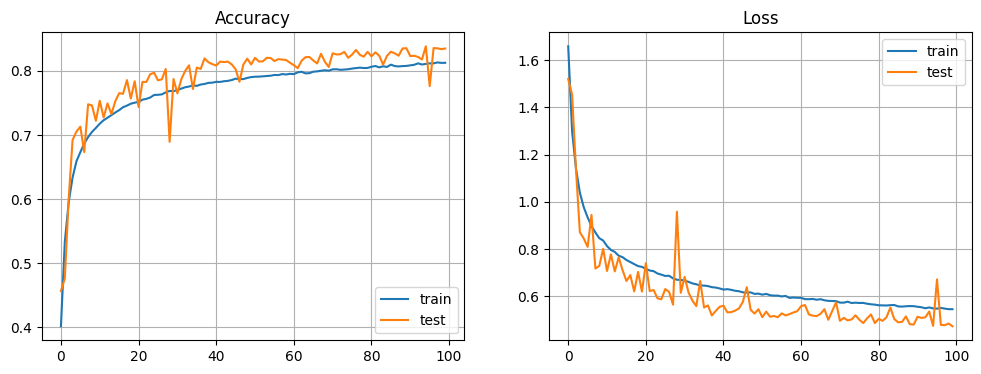

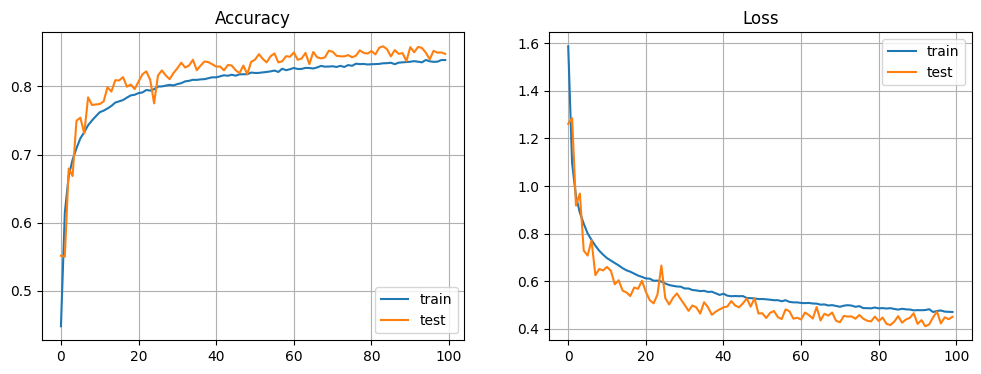

In [74]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model()
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size=100,
    verbose = 0,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

The highest training accuracy was 0.9120 obtained in epoch 199
The final training accuracy was 0.9108
The highest validation accuracy was 0.8606 obtained in epoch 165
The final validation accuracy was 0.8600
The lowest training loss was 0.2431 obtained in epoch 199
The final training loss was 0.2458
The lowest validation loss was 0.4571 obtained in epoch 73
The final validation loss was 0.4747
The highest training accuracy was 0.9230 obtained in epoch 199
The final training accuracy was 0.9220
The highest validation accuracy was 0.8659 obtained in epoch 192
The final validation accuracy was 0.8613
The lowest training loss was 0.2161 obtained in epoch 198
The final training loss was 0.2161
The lowest validation loss was 0.4415 obtained in epoch 59
The final validation loss was 0.4454


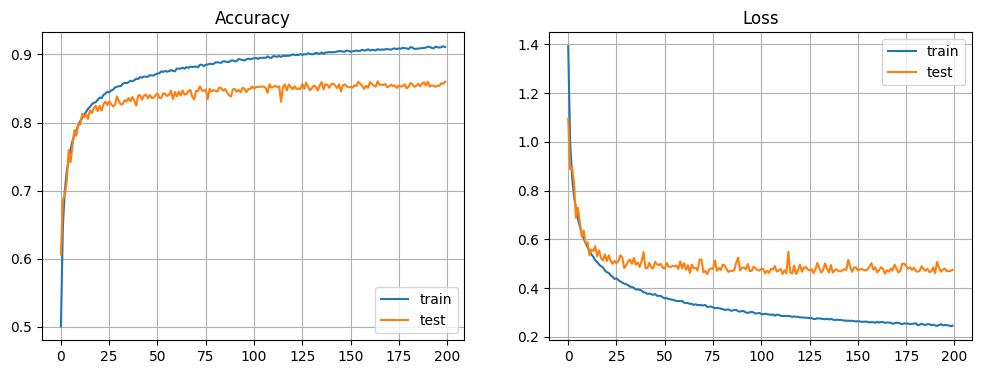

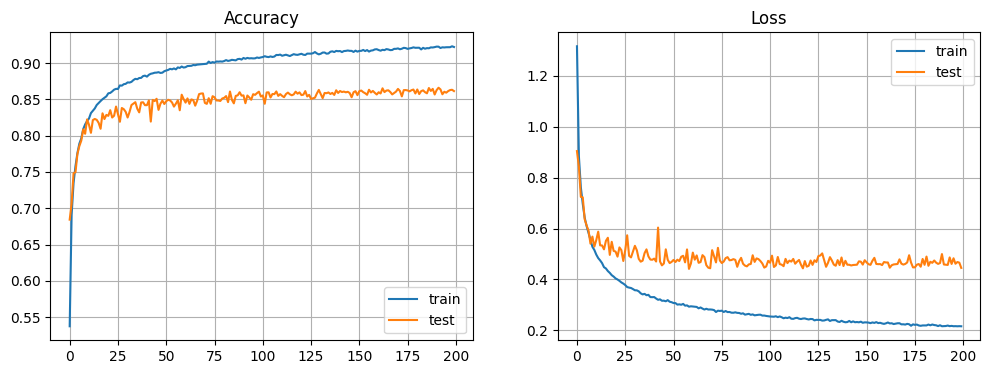

In [75]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model(dropout_rate = 0.3)
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  200,
    batch_size=100,
    verbose = 0,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

Epoch 1/60
500/500 - 10s - 20ms/step - accuracy: 0.5456 - loss: 1.2928 - val_accuracy: 0.1424 - val_loss: 3.8047
Epoch 2/60
500/500 - 3s - 5ms/step - accuracy: 0.6965 - loss: 0.8632 - val_accuracy: 0.7198 - val_loss: 0.8043
Epoch 3/60
500/500 - 2s - 5ms/step - accuracy: 0.7392 - loss: 0.7416 - val_accuracy: 0.7356 - val_loss: 0.7808
Epoch 4/60
500/500 - 2s - 5ms/step - accuracy: 0.7650 - loss: 0.6680 - val_accuracy: 0.7400 - val_loss: 0.7681
Epoch 5/60
500/500 - 2s - 5ms/step - accuracy: 0.7842 - loss: 0.6160 - val_accuracy: 0.7586 - val_loss: 0.7067
Epoch 6/60
500/500 - 3s - 5ms/step - accuracy: 0.7976 - loss: 0.5788 - val_accuracy: 0.7836 - val_loss: 0.6267
Epoch 7/60
500/500 - 3s - 5ms/step - accuracy: 0.8082 - loss: 0.5453 - val_accuracy: 0.7559 - val_loss: 0.7169
Epoch 8/60
500/500 - 2s - 5ms/step - accuracy: 0.8182 - loss: 0.5179 - val_accuracy: 0.7623 - val_loss: 0.6950
Epoch 9/60
500/500 - 2s - 5ms/step - accuracy: 0.8274 - loss: 0.4931 - val_accuracy: 0.7985 - val_loss: 0.6134

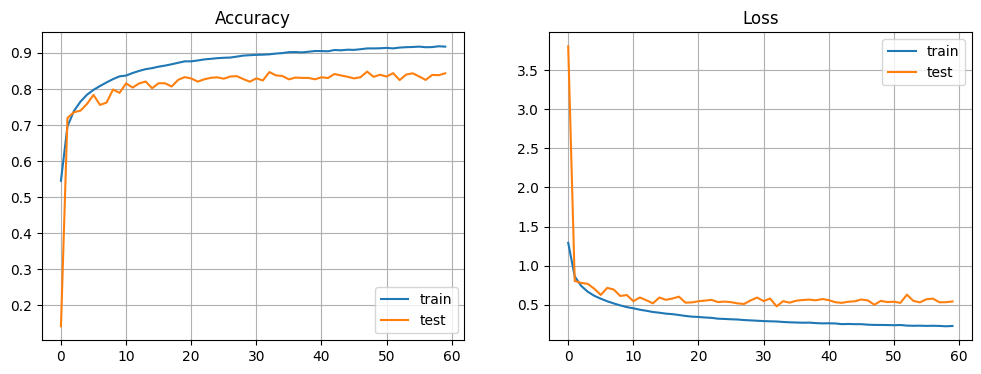

In [76]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model(dropout_rate=0.25)

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  60,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_192 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_193 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_124               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_194 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_195 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_125               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_196 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_197 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_126               │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_49 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
500/500 - 14s - 29ms/step - accuracy: 0.5225 - loss: 1.3638 - val_accuracy: 0.2738 - val_loss: 2.9166
Epoch 2/60
500/500 - 3s - 6ms/step - accuracy: 0.7027 - loss: 0.8452 - val_accuracy: 0.6400 - val_loss: 1.0483
Epoch 3/60
500/500 - 3s - 6ms/step - accuracy: 0.7594 - loss: 0.6892 - val_accuracy: 0.7401 - val_loss: 0.7510
Epoch 4/60
500/500 - 3s - 6ms/step - accuracy: 0.7898 - loss: 0.6017 - val_accuracy: 0.7875 - val_loss: 0.6334
Epoch 5/60
500/500 - 3s - 6ms/step - accuracy: 0.8115 - loss: 0.5421 - val_accuracy: 0.8059 - val_loss: 0.5645
Epoch 6/60
500/500 - 3s - 6ms/step - accuracy: 0.8275 - loss: 0.4947 - val_accuracy: 0.8137 - val_loss: 0.5527
Epoch 7/60
500/500 - 3s - 6ms/step - accuracy: 0.8389 - loss: 0.4578 - val_accuracy: 0.8071 - val_loss: 0.5577
Epoch 8/60
500/500 - 3s - 6ms/step - accuracy: 0.8504 - loss: 0.4256 - val_accuracy: 0.8305 - val_loss: 0.5153
Epoch 9/60
500/500 - 3s - 6ms/step - accuracy: 0.8581 - loss: 0.4021 - val_accuracy: 0.8035 - val_loss: 0.6217

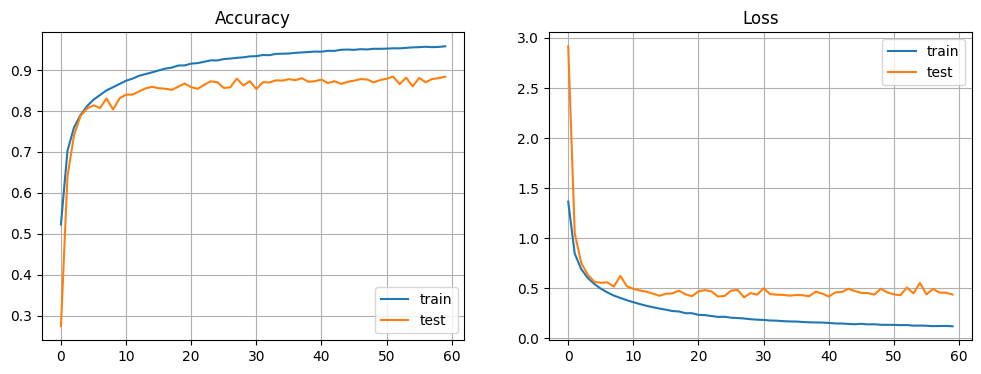

In [77]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dense_units = (128,), dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  for d in dense_units:
    model.add(Dense(d, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,128), dropout_rate=0.25)
model.summary()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  60,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_198 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_199 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_127               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_200 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_201 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_128               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_202 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_203 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_129               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_50 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
391/391 - 26s - 66ms/step - accuracy: 0.5316 - loss: 1.3289 - val_accuracy: 0.3848 - val_loss: 1.9260
Epoch 2/60
391/391 - 3s - 7ms/step - accuracy: 0.7193 - loss: 0.8076 - val_accuracy: 0.6776 - val_loss: 0.9164
Epoch 3/60
391/391 - 3s - 7ms/step - accuracy: 0.7751 - loss: 0.6449 - val_accuracy: 0.6891 - val_loss: 0.9440
Epoch 4/60
391/391 - 3s - 7ms/step - accuracy: 0.8101 - loss: 0.5502 - val_accuracy: 0.7340 - val_loss: 0.8275
Epoch 5/60
391/391 - 3s - 7ms/step - accuracy: 0.8326 - loss: 0.4817 - val_accuracy: 0.7349 - val_loss: 0.8174
Epoch 6/60
391/391 - 3s - 7ms/step - accuracy: 0.8482 - loss: 0.4365 - val_accuracy: 0.8012 - val_loss: 0.5906
Epoch 7/60
391/391 - 3s - 7ms/step - accuracy: 0.8656 - loss: 0.3888 - val_accuracy: 0.8091 - val_loss: 0.5811
Epoch 8/60
391/391 - 3s - 7ms/step - accuracy: 0.8742 - loss: 0.3608 - val_accuracy: 0.7885 - val_loss: 0.6617
Epoch 9/60
391/391 - 3s - 7ms/step - accuracy: 0.8843 - loss: 0.3295 - val_accuracy: 0.8045 - val_loss: 0.5987

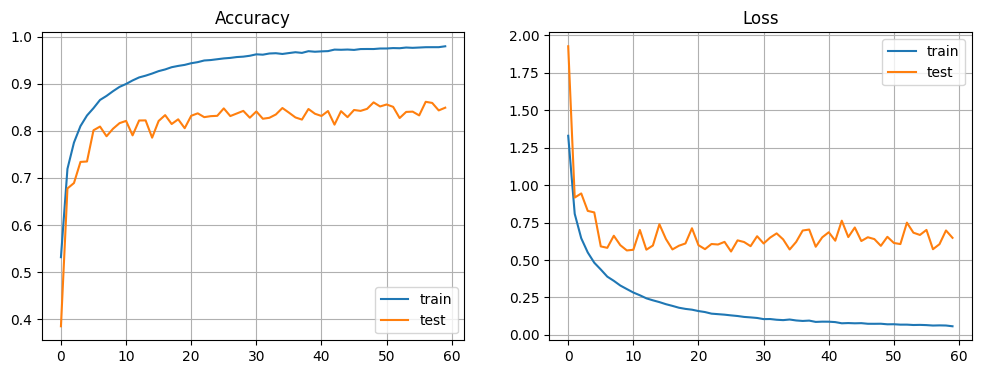

In [78]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dense_units = (128,), dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  for i, c in enumerate(conv_units):
    if i==1:
      model.add(Conv2D(c, kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
    else:
      model.add(Conv2D(c, kernel_size=(3, 3), padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3), padding='same', activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  for d in dense_units:
    model.add(Dense(d, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,128), dropout_rate=0.25)
model.summary()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  60,
    batch_size = 256,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_204 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_205 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_130               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_206 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_207 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_131               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_208 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_209 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_132               │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_51 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
391/391 - 19s - 48ms/step - accuracy: 0.4554 - loss: 1.5319 - val_accuracy: 0.4226 - val_loss: 1.6212
Epoch 2/60
391/391 - 3s - 7ms/step - accuracy: 0.6089 - loss: 1.0933 - val_accuracy: 0.6444 - val_loss: 1.0064
Epoch 3/60
391/391 - 3s - 6ms/step - accuracy: 0.6769 - loss: 0.9047 - val_accuracy: 0.6269 - val_loss: 1.1092
Epoch 4/60
391/391 - 3s - 6ms/step - accuracy: 0.7207 - loss: 0.7887 - val_accuracy: 0.7043 - val_loss: 0.8674
Epoch 5/60
391/391 - 3s - 6ms/step - accuracy: 0.7481 - loss: 0.7146 - val_accuracy: 0.7548 - val_loss: 0.7066
Epoch 6/60
391/391 - 3s - 6ms/step - accuracy: 0.7664 - loss: 0.6597 - val_accuracy: 0.7635 - val_loss: 0.6878
Epoch 7/60
391/391 - 3s - 7ms/step - accuracy: 0.7832 - loss: 0.6187 - val_accuracy: 0.7764 - val_loss: 0.6504
Epoch 8/60
391/391 - 3s - 6ms/step - accuracy: 0.7956 - loss: 0.5798 - val_accuracy: 0.7775 - val_loss: 0.6529
Epoch 9/60
391/391 - 2s - 6ms/step - accuracy: 0.8070 - loss: 0.5475 - val_accuracy: 0.8087 - val_loss: 0.5557

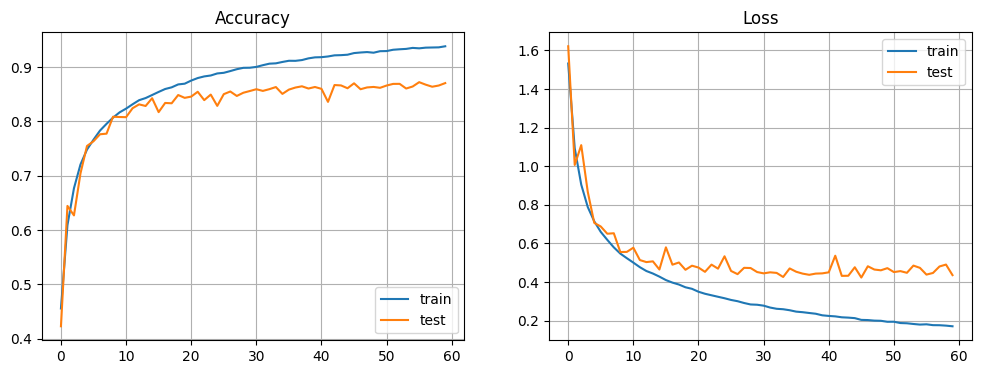

In [79]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64),dense_units = (128,), dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  for d in dense_units:
    model.add(Dense(d, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt= tf.keras.optimizers.SGD(momentum=0.9)
model = cnn_model(conv_units = (32,64,128), dropout_rate=0.25)
model.summary()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  60,
    batch_size = 256,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model(x_test).numpy()
pred2 = model(x_test[:,:,::-1]).numpy()

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test)))